로드 완료: utf-8-sig / 347,299행
✅ 전처리 완료
   수도권  : 36개월
   대구경북: 36개월

STEP 0. 이상치 탐지 (IQR)
  [수도권] 총대출
    Q1=390  Q3=3,500  IQR=3,110
    하한=-4,275  상한=8,165
    이상치: 3,870개 (14.8%)
  [대구/경북] 총대출
    Q1=90  Q3=1,200  IQR=1,110
    하한=-1,575  상한=2,865
    이상치: 29,711개 (11.9%)
  [수도권] 시설자금
    Q1=740  Q3=7,100  IQR=6,360
    하한=-8,800  상한=16,640
    이상치: 679개 (9.0%)
  [대구/경북] 시설자금
    Q1=400  Q3=2,300  IQR=1,900
    하한=-2,450  상한=5,150
    이상치: 7,314개 (8.8%)
  [수도권] 운전자금
    Q1=290  Q3=1,800  IQR=1,510
    하한=-1,975  상한=4,065
    이상치: 3,184개 (14.7%)
  [대구/경북] 운전자금
    Q1=65  Q3=610  IQR=545
    하한=-752  상한=1,428
    이상치: 23,712개 (10.9%)


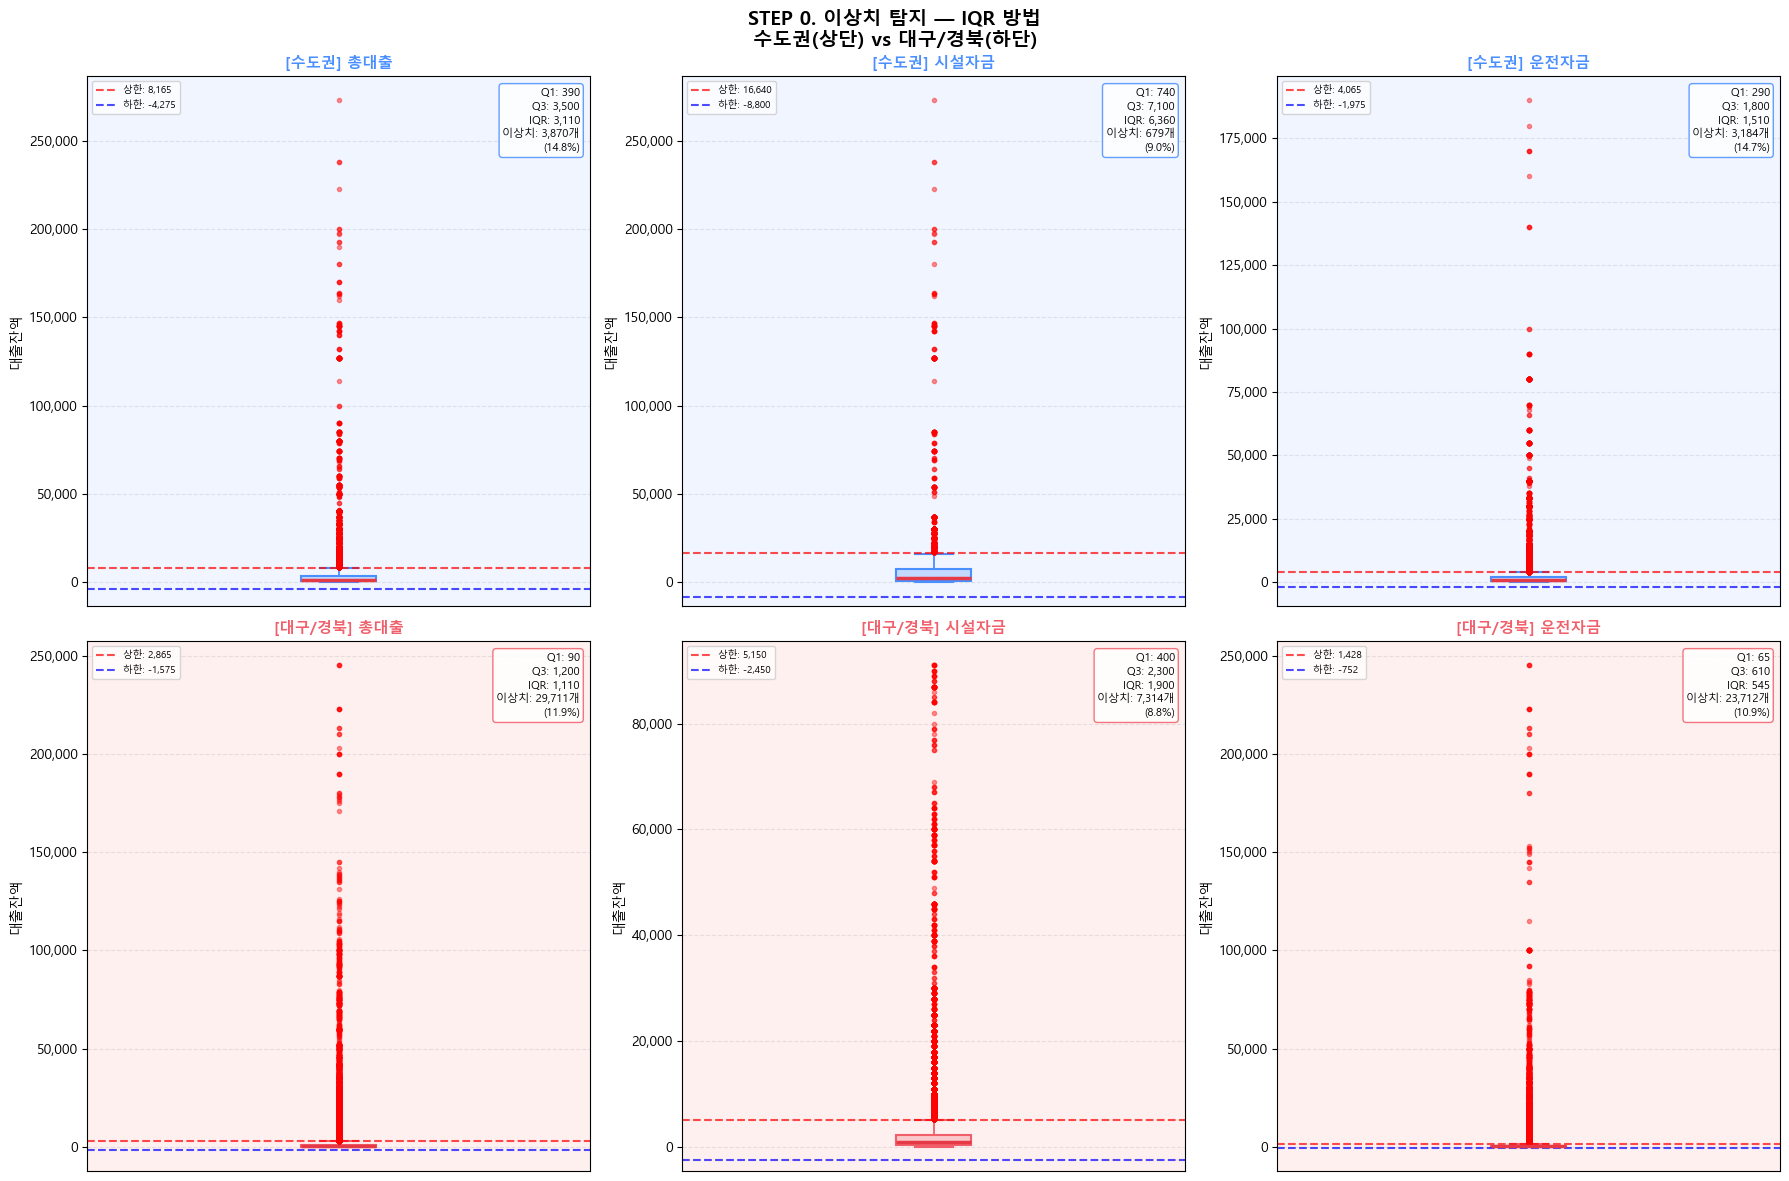

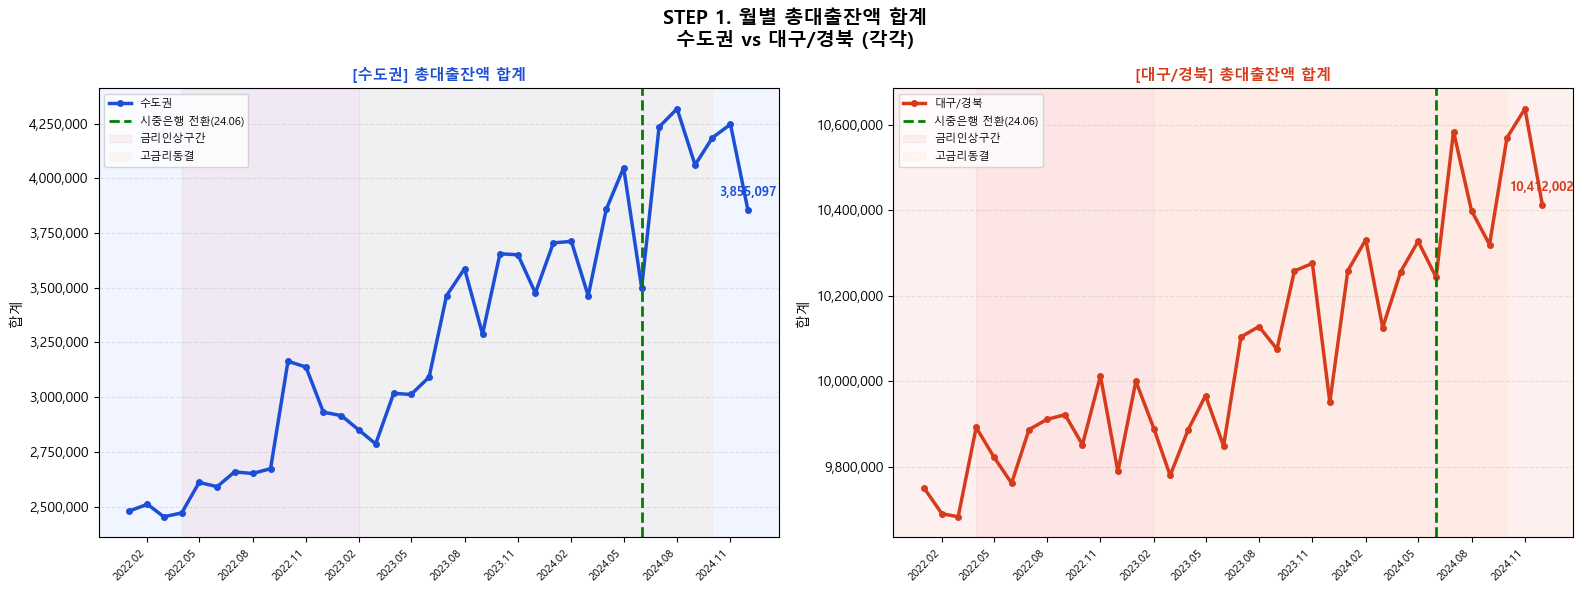

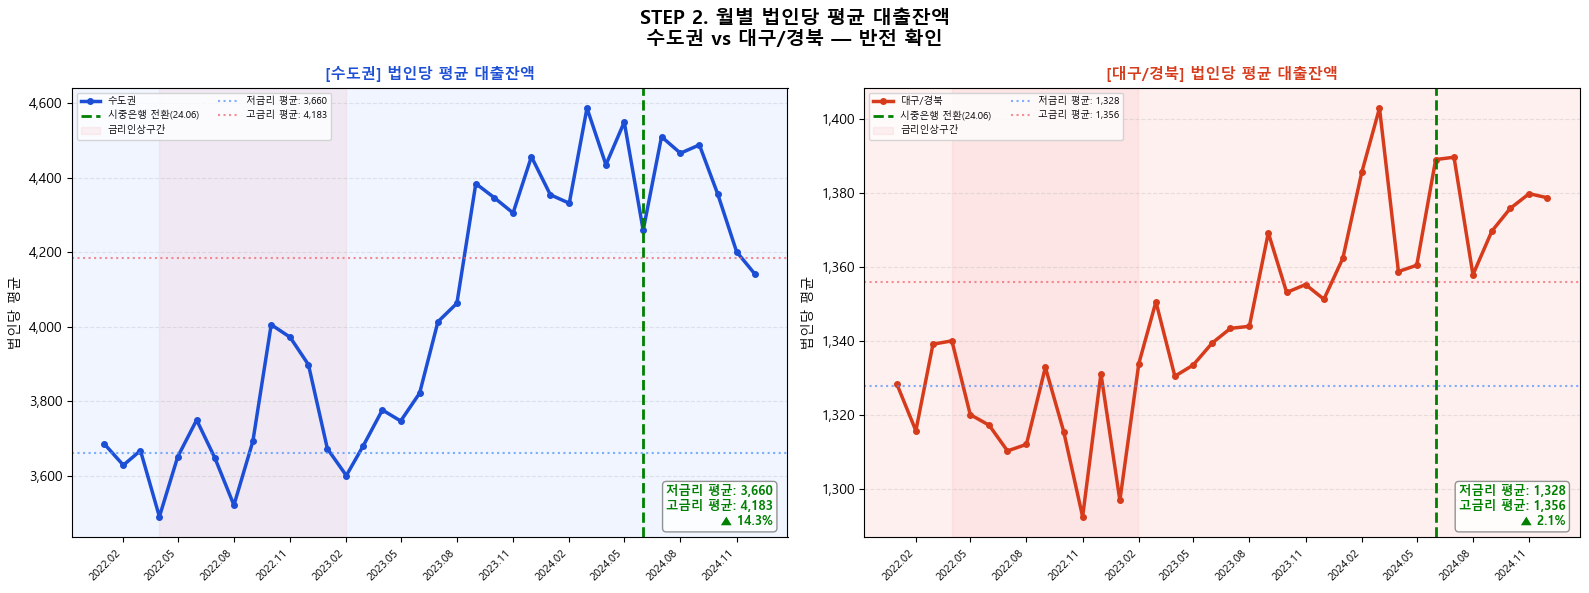

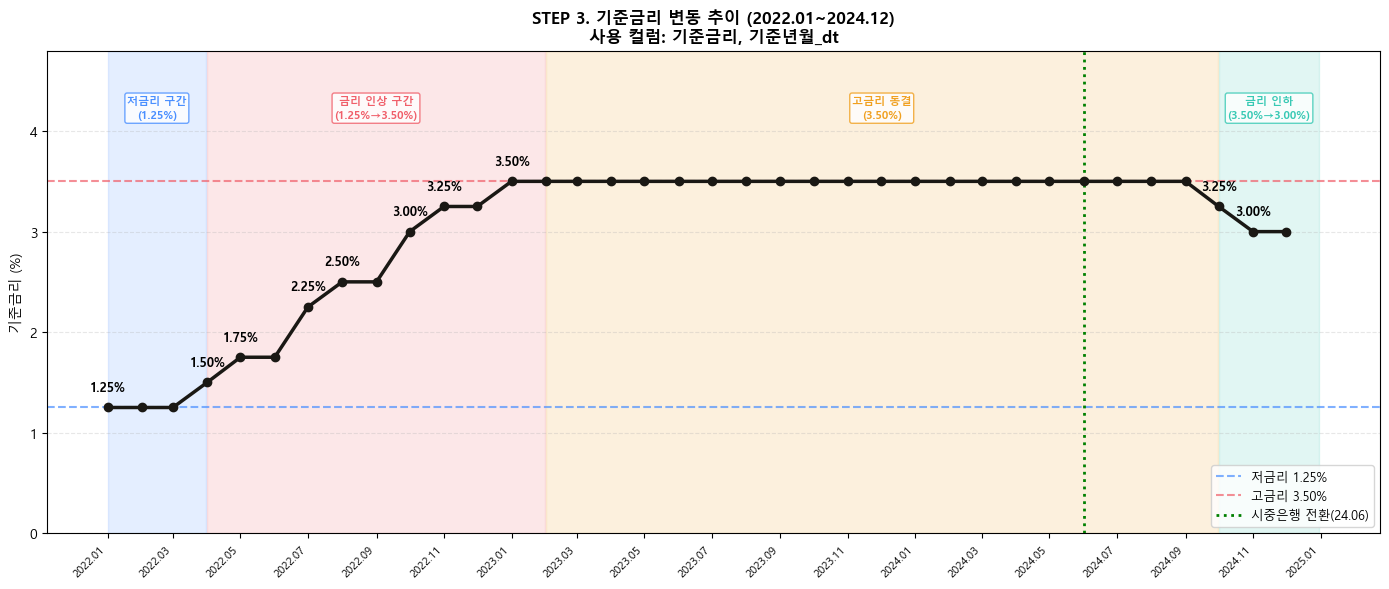

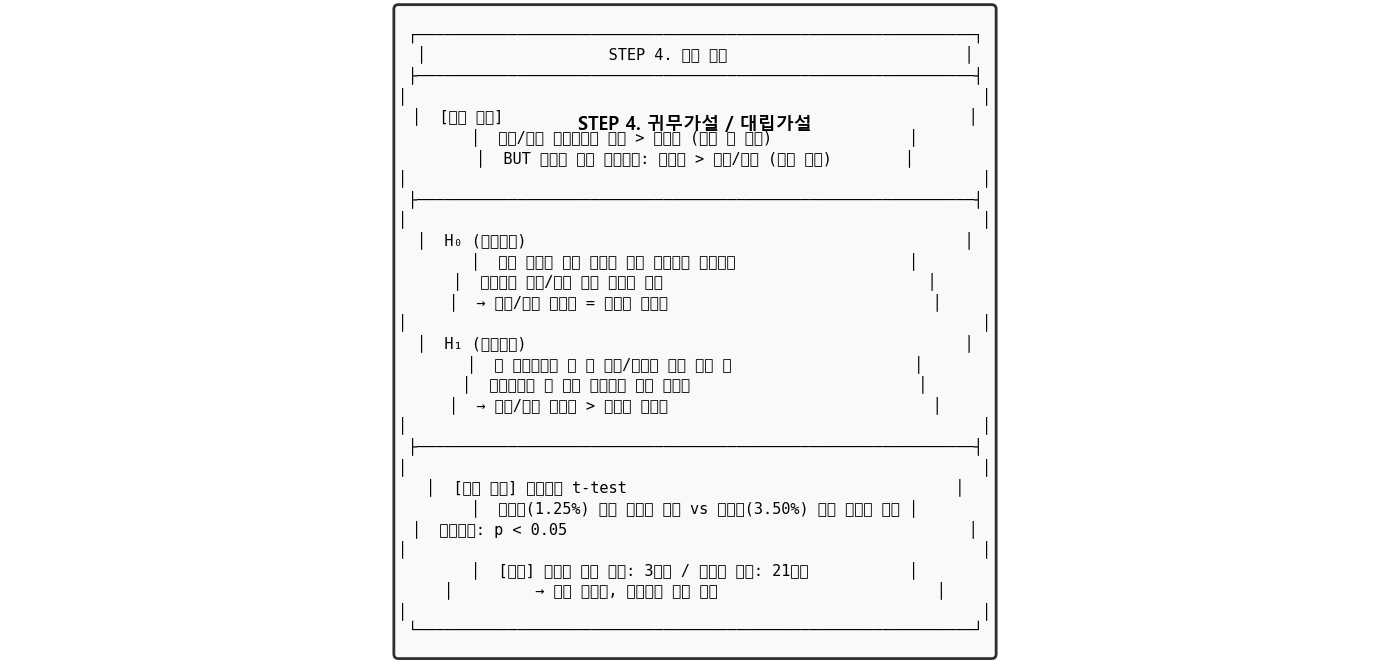

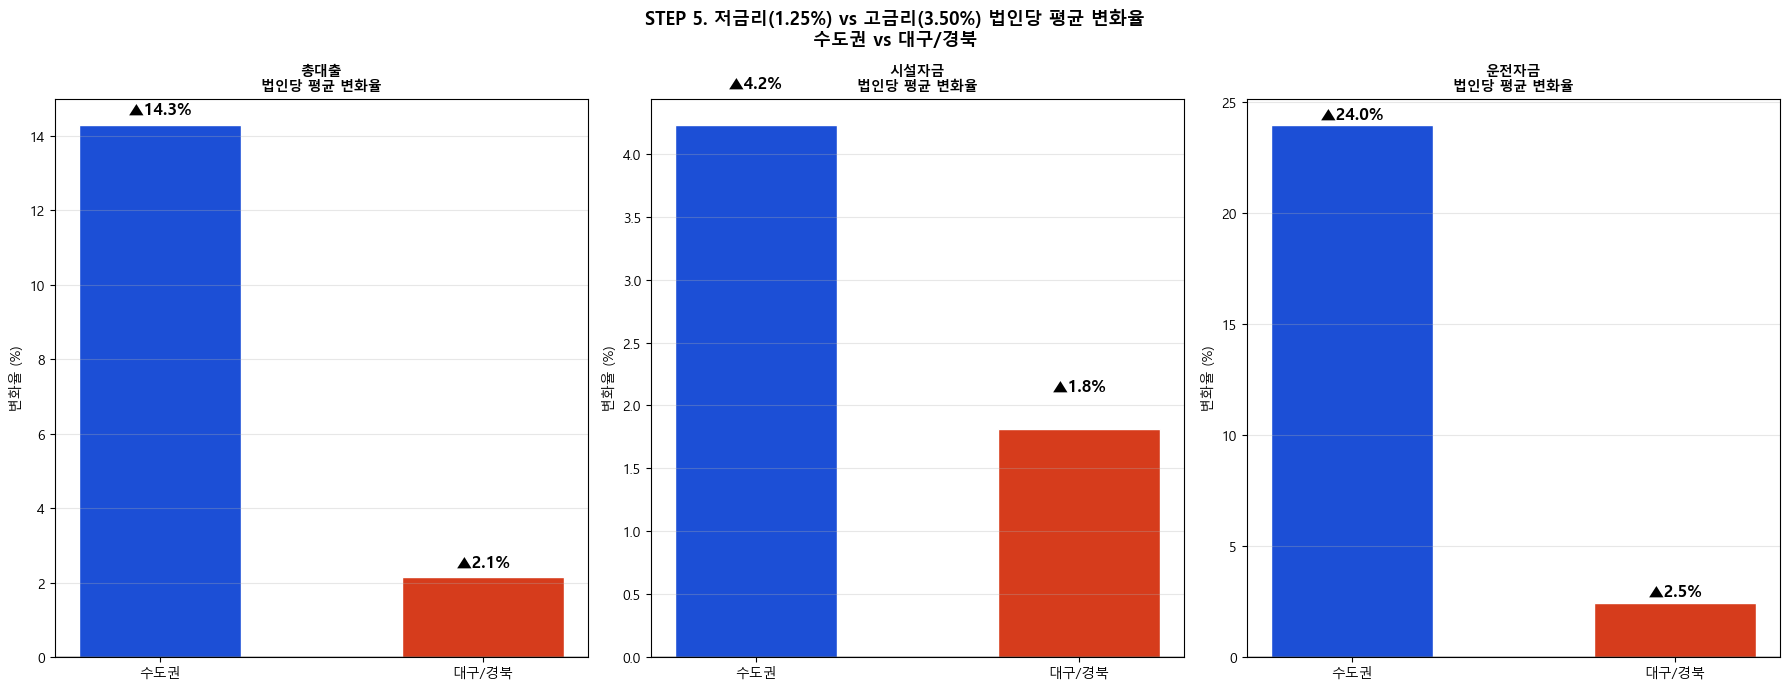


STEP 6. t-test 계산 과정
사용 컬럼: 기준년월_dt × 지역구분 → 총대출잔액/법인수

════════════════════════════════════════════════════════════
  [총대출]
════════════════════════════════════════════════════════════

  [수도권]
  ┌─ STEP 1. 데이터 준비
  │  저금리 구간: n=3개월
  │  고금리 구간: n=21개월
  │
  ├─ STEP 2. 평균 계산
  │  저금리 평균 (x̄₁) = 3,660.0
  │  고금리 평균 (x̄₂) = 4,183.0
  │  변화율 = (4,183.0-3,660.0)/3,660.0×100 = +14.3%
  │
  ├─ STEP 3. 표준편차
  │  s₁ (저금리) = 29.1
  │  s₂ (고금리) = 334.4
  │
  ├─ STEP 4. 표준오차
  │  SE = √(s₁²/n₁ + s₂²/n₂)
  │     = √(281.5 + 5,325.3)
  │     = √5,606.7
  │     = 74.9
  │
  ├─ STEP 5. t값
  │  t = (x̄₂ - x̄₁) / SE
  │    = (4,183.0 - 3,660.0) / 74.9
  │    = 523.0 / 74.9
  │    = 6.9849
  │
  ├─ STEP 6. 자유도 (Welch)
  │  df = 21.57 → 21
  │
  └─ STEP 7. 결론
     t = 2.6566
     p = 0.0144
     유의수준 0.05 기준: H₀ 기각

  [대구/경북]
  ┌─ STEP 1. 데이터 준비
  │  저금리 구간: n=3개월
  │  고금리 구간: n=21개월
  │
  ├─ STEP 2. 평균 계산
  │  저금리 평균 (x̄₁) = 1,327.7
  │  고금리 평균 (x̄₂) = 1,356.0
  │  변화율 = (1,356.0-1,327.7)/1,327.7×100 

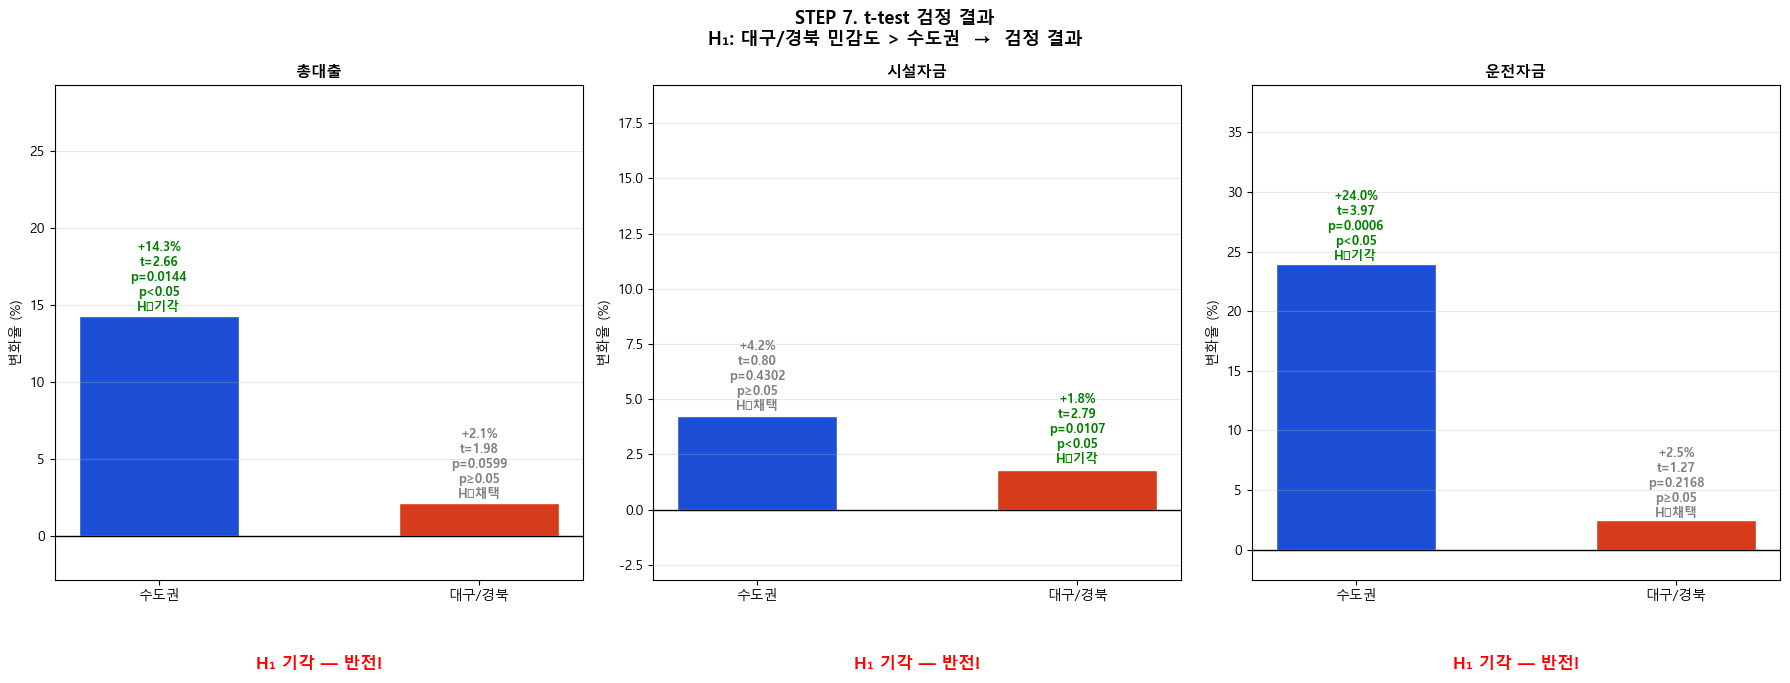


STEP 7. 검정 결과 최종 요약

  구분              수도권 변화율      수도권 p       대경 변화율       대경 p        H1 판단
  ──────────────────────────────────────────────────────────────
  총대출              +14.3%     0.0144        +2.1%     0.0599       기각(반전)
  시설자금              +4.2%     0.4302        +1.8%     0.0107       기각(반전)
  운전자금             +24.0%     0.0006        +2.5%     0.2168       기각(반전)

  결론: H₁ 기각
  → 대구경북이 더 민감하지 않다
  → 오히려 수도권이 금리 변동에 더 민감하게 반응
  → 수도권 집중 공략이 전략적으로 유효


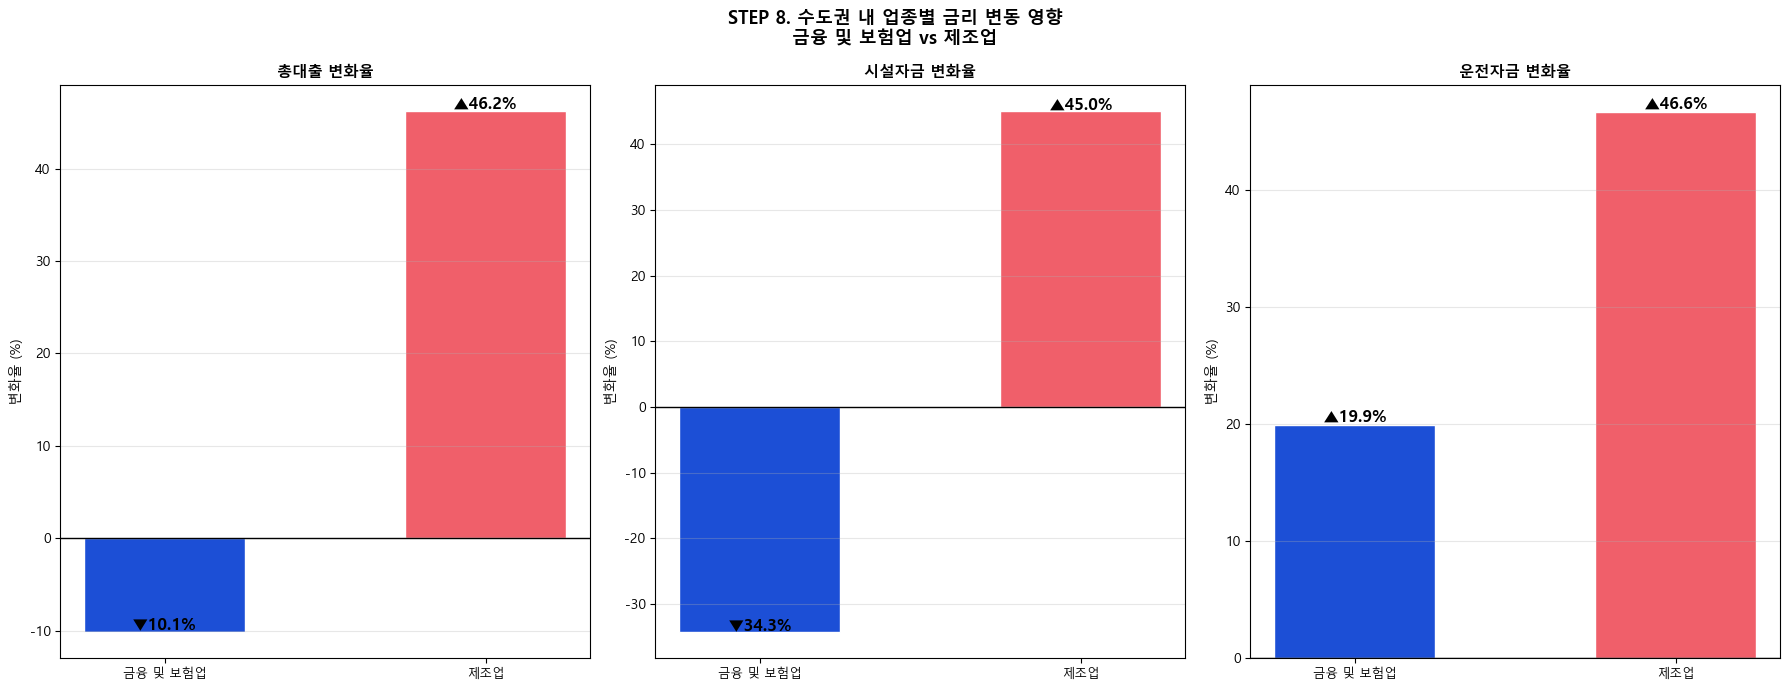


STEP 8. 최종 전략 방향

  [금융 및 보험업] 총대출 변화율: ▼10.1%
    저금리 법인당 평균: 14,307
    고금리 법인당 평균: 12,856
  [제조업] 총대출 변화율: ▲46.2%
    저금리 법인당 평균: 1,856
    고금리 법인당 평균: 2,713

  → 수도권에서 금리 변동에 가장 민감한 업종:
    제조업 (+46.2%)

  전략 제안:
  금리 인하 지금, 제조업 비전담 법인에
  RM 즉시 배정 → 운전자금 한도 확대 선제 제안


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ══════════════════════════════════════════════════════
# 데이터 로드 및 전처리
# ══════════════════════════════════════════════════════
path = (
    "C:\\Users\\campus4D023\\Desktop\\"
    "(아이엠뱅크) 2025 교육용 데이터\\"
    "(아이엠뱅크) 2025 교육용 데이터.csv"
)
df = None
for encoding in ['utf-8-sig','utf-8','euc-kr','cp949','latin1']:
    try:
        df = pd.read_csv(path, encoding=encoding)
        print(f'로드 완료: {encoding} / {len(df):,}행')
        break
    except:
        continue

def to_num(s):
    return pd.to_numeric(
        s.astype(str).str.replace(',','').str.strip(),
        errors='coerce'
    )

df['기준년월_dt'] = pd.to_datetime(
    df['기준년월'].astype(str), format='%Y%m'
)
for col in ['여신_운전자금대출잔액','여신_시설자금대출잔액']:
    if col in df.columns:
        df[col] = to_num(df[col])

df['총대출잔액'] = (
    df['여신_운전자금대출잔액'].fillna(0)
    + df['여신_시설자금대출잔액'].fillna(0)
)

def classify_region(sido):
    if pd.isna(sido): return '기타/미상'
    if any(k in sido for k in ['대구','경북','경상북도']):
        return '대구/경북'
    if any(k in sido for k in ['서울','경기','인천']):
        return '수도권'
    return '기타지방'

df['지역구분'] = df['사업장_시도'].apply(classify_region)

macro_data = {
    '기준년월': [
        202201,202202,202203,202204,202205,202206,
        202207,202208,202209,202210,202211,202212,
        202301,202302,202303,202304,202305,202306,
        202307,202308,202309,202310,202311,202312,
        202401,202402,202403,202404,202405,202406,
        202407,202408,202409,202410,202411,202412
    ],
    '기준금리': [
        1.25,1.25,1.25,1.50,1.75,1.75,
        2.25,2.50,2.50,3.00,3.25,3.25,
        3.50,3.50,3.50,3.50,3.50,3.50,
        3.50,3.50,3.50,3.50,3.50,3.50,
        3.50,3.50,3.50,3.50,3.50,3.50,
        3.50,3.50,3.50,3.25,3.00,3.00
    ]
}
df_macro = pd.DataFrame(macro_data)
df_macro['기준년월_dt'] = pd.to_datetime(
    df_macro['기준년월'].astype(str), format='%Y%m'
)
df = df.merge(
    df_macro[['기준년월_dt','기준금리']],
    on='기준년월_dt', how='left'
)
df['금리구분'] = np.where(
    df['기준금리']==1.25, '저금리(1.25%)',
    np.where(df['기준금리']==3.50, '고금리(3.50%)', '제외')
)

df_2r = df[df['지역구분'].isin(['수도권','대구/경북'])].copy()

# 월별 집계
monthly = df_2r.groupby(
    ['기준년월_dt','지역구분']
).agg(
    총대출_합계   = ('총대출잔액',               'sum'),
    시설자금_합계 = ('여신_시설자금대출잔액',     'sum'),
    운전자금_합계 = ('여신_운전자금대출잔액',     'sum'),
    법인수        = ('총대출잔액',               'count'),
    기준금리      = ('기준금리',                 'first'),
).reset_index()

monthly['총대출_법인당']   = monthly['총대출_합계']   / monthly['법인수']
monthly['시설자금_법인당'] = monthly['시설자금_합계'] / monthly['법인수']
monthly['운전자금_법인당'] = monthly['운전자금_합계'] / monthly['법인수']
monthly['금리구분'] = np.where(
    monthly['기준금리']==1.25, '저금리(1.25%)',
    np.where(monthly['기준금리']==3.50, '고금리(3.50%)', '제외')
)

metro = monthly[monthly['지역구분']=='수도권'].sort_values('기준년월_dt')
daegu = monthly[monthly['지역구분']=='대구/경북'].sort_values('기준년월_dt')

전환시점 = pd.Timestamp('2024-06-01')

print('✅ 전처리 완료')
print(f'   수도권  : {len(metro)}개월')
print(f'   대구경북: {len(daegu)}개월')

# ══════════════════════════════════════════════════════
# STEP 0. 이상치 탐지 — IQR 방법
# 사용 컬럼: 총대출잔액, 여신_시설자금대출잔액,
#            여신_운전자금대출잔액
# ══════════════════════════════════════════════════════
print('\n' + '='*60)
print('STEP 0. 이상치 탐지 (IQR)')
print('='*60)

analysis_cols = [
    ('총대출잔액',           '총대출'),
    ('여신_시설자금대출잔액', '시설자금'),
    ('여신_운전자금대출잔액', '운전자금'),
]

iqr_results = {}
for col, label in analysis_cols:
    for region in ['수도권','대구/경북']:
        data = df_2r[
            (df_2r['지역구분']==region) &
            (df_2r[col].fillna(0)>0)
        ][col].dropna()

        Q1  = data.quantile(0.25)
        Q3  = data.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5*IQR
        upper = Q3 + 1.5*IQR
        outliers = data[(data<lower)|(data>upper)]
        ratio = len(outliers)/len(data)*100

        iqr_results[f'{region}_{label}'] = {
            'region': region, 'label': label,
            'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
            'lower': lower, 'upper': upper,
            'n_outlier': len(outliers),
            'ratio': ratio, 'data': data
        }
        print(f'  [{region}] {label}')
        print(f'    Q1={Q1:,.0f}  Q3={Q3:,.0f}  IQR={IQR:,.0f}')
        print(f'    하한={lower:,.0f}  상한={upper:,.0f}')
        print(f'    이상치: {len(outliers):,}개 ({ratio:.1f}%)')

# 이상치 박스플롯
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(
    'STEP 0. 이상치 탐지 — IQR 방법\n'
    '수도권(상단) vs 대구/경북(하단)',
    fontsize=14, fontweight='bold'
)

palette = {'수도권':'#4a8fff','대구/경북':'#f05f6a'}

for row_idx, region in enumerate(['수도권','대구/경북']):
    for col_idx, (col, label) in enumerate(analysis_cols):
        ax = axes[row_idx][col_idx]
        color = palette[region]
        key = f'{region}_{label}'
        res = iqr_results[key]
        data = res['data']

        bp = ax.boxplot(
            data.values,
            patch_artist=True,
            showfliers=True,
            flierprops=dict(
                marker='o', markerfacecolor='red',
                markersize=3, alpha=0.4,
                markeredgecolor='red'
            ),
            boxprops=dict(facecolor=color+'44',
                         color=color, linewidth=1.5),
            medianprops=dict(color='#e63946', linewidth=2.5),
            whiskerprops=dict(color=color, linewidth=1.3),
            capprops=dict(color=color, linewidth=1.5),
        )

        # IQR 경계선
        ax.axhline(res['upper'], color='red',
                   linestyle='--', linewidth=1.5,
                   alpha=0.7, label=f'상한: {res["upper"]:,.0f}')
        ax.axhline(res['lower'], color='blue',
                   linestyle='--', linewidth=1.5,
                   alpha=0.7, label=f'하한: {res["lower"]:,.0f}')

        ax.text(
            0.98, 0.98,
            f'Q1: {res["Q1"]:,.0f}\n'
            f'Q3: {res["Q3"]:,.0f}\n'
            f'IQR: {res["IQR"]:,.0f}\n'
            f'이상치: {res["n_outlier"]:,}개\n'
            f'({res["ratio"]:.1f}%)',
            transform=ax.transAxes,
            ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='white',
                      edgecolor=color, alpha=0.85)
        )

        ax.set_title(f'[{region}] {label}',
                     fontsize=11, fontweight='bold', color=color)
        ax.set_xticks([])
        ax.set_ylabel('대출잔액')
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x,_: f'{x:,.0f}')
        )
        ax.legend(fontsize=7, loc='upper left')
        ax.set_facecolor(
            '#f0f5ff' if region=='수도권' else '#fff0f0'
        )
        ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════
# STEP 1. 총대출잔액 합계 — 대구경북 > 수도권
# 사용 컬럼: 총대출잔액, 기준년월_dt, 지역구분
# ══════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'STEP 1. 월별 총대출잔액 합계\n'
    '수도권 vs 대구/경북 (각각)',
    fontsize=14, fontweight='bold'
)

for ax, region, color, bg in zip(
    axes,
    ['수도권','대구/경북'],
    ['#1c4fd6','#d63c1c'],
    ['#f0f5ff','#fff0f0']
):
    data = monthly[monthly['지역구분']==region].sort_values('기준년월_dt')
    ax.plot(data['기준년월_dt'], data['총대출_합계'],
            color=color, linewidth=2.5,
            marker='o', markersize=4, label=region)
    ax.axvline(전환시점, color='green', linestyle='--',
               linewidth=2, label='시중은행 전환(24.06)')
    ax.axvspan(pd.Timestamp('2022-04-01'),
               pd.Timestamp('2023-01-31'),
               alpha=0.08, color='#f05f6a', label='금리인상구간')
    ax.axvspan(pd.Timestamp('2023-02-01'),
               pd.Timestamp('2024-09-30'),
               alpha=0.05, color='#f0a020', label='고금리동결')

    # 끝값 표시
    last = data.iloc[-1]
    ax.annotate(
        f'{last["총대출_합계"]:,.0f}',
        (last['기준년월_dt'], last['총대출_합계']),
        textcoords='offset points', xytext=(0,10),
        ha='center', fontsize=9, fontweight='bold', color=color
    )

    ax.set_title(f'[{region}] 총대출잔액 합계',
                 fontsize=11, fontweight='bold', color=color)
    ax.set_ylabel('합계')
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x,_: f'{x:,.0f}')
    )
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y.%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(),
             rotation=45, ha='right', fontsize=8)
    ax.legend(fontsize=8)
    ax.set_facecolor(bg)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════
# STEP 2. 법인당 평균 대출잔액 — 수도권 > 대구경북
# 사용 컬럼: 총대출잔액/법인수 (파생)
# ══════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'STEP 2. 월별 법인당 평균 대출잔액\n'
    '수도권 vs 대구/경북 — 반전 확인',
    fontsize=14, fontweight='bold'
)

for ax, region, color, bg in zip(
    axes,
    ['수도권','대구/경북'],
    ['#1c4fd6','#d63c1c'],
    ['#f0f5ff','#fff0f0']
):
    data = monthly[monthly['지역구분']==region].sort_values('기준년월_dt')
    ax.plot(data['기준년월_dt'], data['총대출_법인당'],
            color=color, linewidth=2.5,
            marker='o', markersize=4, label=region)
    ax.axvline(전환시점, color='green', linestyle='--',
               linewidth=2, label='시중은행 전환(24.06)')
    ax.axvspan(pd.Timestamp('2022-04-01'),
               pd.Timestamp('2023-01-31'),
               alpha=0.08, color='#f05f6a', label='금리인상구간')

    # 저금리/고금리 평균선
    low_mean = data[data['금리구분']=='저금리(1.25%)']['총대출_법인당'].mean()
    high_mean = data[data['금리구분']=='고금리(3.50%)']['총대출_법인당'].mean()
    ax.axhline(low_mean, color='#4a8fff', linestyle=':',
               linewidth=1.5, alpha=0.7,
               label=f'저금리 평균: {low_mean:,.0f}')
    ax.axhline(high_mean, color='#f05f6a', linestyle=':',
               linewidth=1.5, alpha=0.7,
               label=f'고금리 평균: {high_mean:,.0f}')

    변화율 = (high_mean-low_mean)/low_mean*100
    방향 = '▲' if 변화율>0 else '▼'
    ax.text(0.98, 0.02,
            f'저금리 평균: {low_mean:,.0f}\n'
            f'고금리 평균: {high_mean:,.0f}\n'
            f'{방향} {abs(변화율):.1f}%',
            transform=ax.transAxes,
            ha='right', va='bottom', fontsize=9,
            fontweight='bold',
            color='green' if 변화율>0 else 'red',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='white', edgecolor='gray',
                      alpha=0.85))

    ax.set_title(f'[{region}] 법인당 평균 대출잔액',
                 fontsize=11, fontweight='bold', color=color)
    ax.set_ylabel('법인당 평균')
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x,_: f'{x:,.0f}')
    )
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y.%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(),
             rotation=45, ha='right', fontsize=8)
    ax.legend(fontsize=7, ncol=2)
    ax.set_facecolor(bg)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════
# STEP 3. 금리 추이 — 구간별 표시
# 사용 컬럼: 기준금리, 기준년월_dt
# ══════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 6))

# 구간 음영
구간_info = [
    ('2022-01-01','2022-03-31','#4a8fff','저금리 구간\n(1.25%)'),
    ('2022-04-01','2023-01-31','#f05f6a','금리 인상 구간\n(1.25%→3.50%)'),
    ('2023-02-01','2024-09-30','#f0a020','고금리 동결\n(3.50%)'),
    ('2024-10-01','2024-12-31','#38c9b4','금리 인하\n(3.50%→3.00%)'),
]

for start, end, color, label in 구간_info:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               alpha=0.15, color=color)
    mid = pd.Timestamp(start) + (pd.Timestamp(end)-pd.Timestamp(start))/2
    ax.text(mid, 4.1, label,
            ha='center', va='bottom', fontsize=8,
            fontweight='bold', color=color,
            bbox=dict(boxstyle='round,pad=0.2',
                      facecolor='white', edgecolor=color,
                      alpha=0.8))

ax.plot(df_macro['기준년월_dt'], df_macro['기준금리'],
        color='#1a1814', linewidth=2.5,
        marker='o', markersize=6, zorder=5)

# 변동 시점 수치
prev = None
for _, row in df_macro.iterrows():
    if row['기준금리'] != prev:
        ax.annotate(
            f'{row["기준금리"]:.2f}%',
            (row['기준년월_dt'], row['기준금리']),
            textcoords='offset points', xytext=(0,12),
            ha='center', fontsize=9, fontweight='bold'
        )
        prev = row['기준금리']

# 분석 구간 강조
ax.axhline(1.25, color='#4a8fff', linestyle='--',
           linewidth=1.5, alpha=0.7, label='저금리 1.25%')
ax.axhline(3.50, color='#f05f6a', linestyle='--',
           linewidth=1.5, alpha=0.7, label='고금리 3.50%')
ax.axvline(전환시점, color='green', linestyle=':',
           linewidth=2, label='시중은행 전환(24.06)')

ax.set_title('STEP 3. 기준금리 변동 추이 (2022.01~2024.12)\n'
             '사용 컬럼: 기준금리, 기준년월_dt',
             fontsize=12, fontweight='bold')
ax.set_ylabel('기준금리 (%)')
ax.set_ylim(0, 4.8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y.%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(),
         rotation=45, ha='right', fontsize=8)
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════
# STEP 4. 가설 설정 출력
# ══════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

가설_text = """
┌─────────────────────────────────────────────────────────────┐
│                    STEP 4. 가설 설정                          │
├─────────────────────────────────────────────────────────────┤
│                                                               │
│  [분석 배경]                                                   │
│  대구/경북 총대출잔액 합계 > 수도권 (법인 수 차이)               │
│  BUT 법인당 평균 대출잔액: 수도권 > 대구/경북 (규모 차이)        │
│                                                               │
├─────────────────────────────────────────────────────────────┤
│                                                               │
│  H₀ (귀무가설)                                                │
│  금리 변동에 따른 법인당 평균 대출잔액 변화율이                   │
│  수도권과 대구/경북 간에 차이가 없다                             │
│  → 대구/경북 변화율 = 수도권 변화율                             │
│                                                               │
│  H₁ (대립가설)                                                │
│  총 대출잔액이 더 큰 대구/경북이 금리 변동 시                    │
│  수도권보다 더 높은 변화율을 보일 것이다                         │
│  → 대구/경북 변화율 > 수도권 변화율                             │
│                                                               │
├─────────────────────────────────────────────────────────────┤
│                                                               │
│  [검정 방법] 독립표본 t-test                                    │
│  저금리(1.25%) 구간 법인당 평균 vs 고금리(3.50%) 구간 법인당 평균 │
│  유의수준: p < 0.05                                            │
│                                                               │
│  [한계] 저금리 구간 표본: 3개월 / 고금리 구간: 21개월           │
│         → 표본 불균형, 상관관계 수준 분석                        │
│                                                               │
└─────────────────────────────────────────────────────────────┘
"""

ax.text(0.5, 0.5, 가설_text,
        transform=ax.transAxes,
        ha='center', va='center',
        fontsize=11,
        fontfamily='monospace',
        bbox=dict(boxstyle='round',
                  facecolor='#f8f9fa',
                  edgecolor='#1a1814',
                  linewidth=2,
                  alpha=0.9))
ax.set_title('STEP 4. 귀무가설 / 대립가설',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════
# STEP 5. 지역별 변화율 비교
# 저금리 vs 고금리 법인당 평균
# 사용 컬럼: 총대출잔액/법인수, 기준금리
# ══════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle(
    'STEP 5. 저금리(1.25%) vs 고금리(3.50%) 법인당 평균 변화율\n'
    '수도권 vs 대구/경북',
    fontsize=13, fontweight='bold'
)

cols = [
    ('총대출_법인당',   '총대출'),
    ('시설자금_법인당', '시설자금'),
    ('운전자금_법인당', '운전자금'),
]

rate_data = {}
for col, label in cols:
    rate_data[label] = {}
    for region, data in [('수도권',metro),('대구/경북',daegu)]:
        low  = data[data['금리구분']=='저금리(1.25%)'][col].dropna()
        high = data[data['금리구분']=='고금리(3.50%)'][col].dropna()
        if len(low)==0 or len(high)==0: continue
        변화율 = (high.mean()-low.mean())/low.mean()*100
        rate_data[label][region] = {
            'low': low.mean(), 'high': high.mean(),
            '변화율': 변화율
        }

for ax, (col, label) in zip(axes, cols):
    if label not in rate_data: continue
    regions = list(rate_data[label].keys())
    변화율s = [rate_data[label][r]['변화율'] for r in regions]
    colors  = ['#1c4fd6','#d63c1c']

    bars = ax.bar(regions, 변화율s,
                  color=colors, edgecolor='white', width=0.5)
    for bar, val in zip(bars, 변화율s):
        방향 = '▲' if val>=0 else '▼'
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.3,
                f'{방향}{abs(val):.1f}%',
                ha='center', fontsize=12, fontweight='bold')

    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(f'{label}\n법인당 평균 변화율',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel('변화율 (%)')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════
# STEP 6. t-test 계산 과정 전체 출력
# 사용 컬럼: 총대출잔액/법인수 (월별 법인당 평균)
# ══════════════════════════════════════════════════════
print('\n' + '='*65)
print('STEP 6. t-test 계산 과정')
print('사용 컬럼: 기준년월_dt × 지역구분 → 총대출잔액/법인수')
print('='*65)

ttest_results = {}

for col, label in cols:
    print(f'\n{"═"*60}')
    print(f'  [{label}]')
    print(f'{"═"*60}')
    ttest_results[label] = {}

    for region, data in [('수도권',metro),('대구/경북',daegu)]:
        low  = data[data['금리구분']=='저금리(1.25%)'][col].dropna()
        high = data[data['금리구분']=='고금리(3.50%)'][col].dropna()
        if len(low)<2 or len(high)<2: continue

        # 수동 계산 과정
        x1_bar = low.mean()
        x2_bar = high.mean()
        s1     = low.std(ddof=1)
        s2     = high.std(ddof=1)
        n1     = len(low)
        n2     = len(high)
        SE     = np.sqrt(s1**2/n1 + s2**2/n2)
        t_man  = (x2_bar - x1_bar) / SE

        # Welch 자유도
        num = (s1**2/n1 + s2**2/n2)**2
        den = (s1**2/n1)**2/(n1-1) + (s2**2/n2)**2/(n2-1)
        df_w = num/den

        # scipy t-test
        t_stat, p = stats.ttest_ind(
            high, low, alternative='two-sided'
        )
        변화율 = (x2_bar-x1_bar)/x1_bar*100

        ttest_results[label][region] = {
            't': t_stat, 'p': p, '변화율': 변화율,
            'low': x1_bar, 'high': x2_bar
        }

        결과 = 'H₀ 기각' if p<0.05 else 'H₀ 채택'
        print(f'\n  [{region}]')
        print(f'  ┌─ STEP 1. 데이터 준비')
        print(f'  │  저금리 구간: n={n1}개월')
        print(f'  │  고금리 구간: n={n2}개월')
        print(f'  │')
        print(f'  ├─ STEP 2. 평균 계산')
        print(f'  │  저금리 평균 (x̄₁) = {x1_bar:,.1f}')
        print(f'  │  고금리 평균 (x̄₂) = {x2_bar:,.1f}')
        print(f'  │  변화율 = ({x2_bar:,.1f}-{x1_bar:,.1f})/{x1_bar:,.1f}×100 = {변화율:+.1f}%')
        print(f'  │')
        print(f'  ├─ STEP 3. 표준편차')
        print(f'  │  s₁ (저금리) = {s1:,.1f}')
        print(f'  │  s₂ (고금리) = {s2:,.1f}')
        print(f'  │')
        print(f'  ├─ STEP 4. 표준오차')
        print(f'  │  SE = √(s₁²/n₁ + s₂²/n₂)')
        print(f'  │     = √({s1**2/n1:,.1f} + {s2**2/n2:,.1f})')
        print(f'  │     = √{s1**2/n1+s2**2/n2:,.1f}')
        print(f'  │     = {SE:,.1f}')
        print(f'  │')
        print(f'  ├─ STEP 5. t값')
        print(f'  │  t = (x̄₂ - x̄₁) / SE')
        print(f'  │    = ({x2_bar:,.1f} - {x1_bar:,.1f}) / {SE:,.1f}')
        print(f'  │    = {x2_bar-x1_bar:,.1f} / {SE:,.1f}')
        print(f'  │    = {t_man:.4f}')
        print(f'  │')
        print(f'  ├─ STEP 6. 자유도 (Welch)')
        print(f'  │  df = {df_w:.2f} → {int(df_w)}')
        print(f'  │')
        print(f'  └─ STEP 7. 결론')
        print(f'     t = {t_stat:.4f}')
        print(f'     p = {p:.4f}')
        print(f'     유의수준 0.05 기준: {결과}')

# ══════════════════════════════════════════════════════
# STEP 7. t-test 검정 결과 시각화
# ══════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle(
    'STEP 7. t-test 검정 결과\n'
    'H₁: 대구/경북 민감도 > 수도권  →  검정 결과',
    fontsize=13, fontweight='bold'
)

for ax, (col, label) in zip(axes, cols):
    if label not in ttest_results: continue

    regions = ['수도권','대구/경북']
    변화율s = [
        ttest_results[label].get(r,{}).get('변화율',0)
        for r in regions
    ]
    p_vals = [
        ttest_results[label].get(r,{}).get('p',1)
        for r in regions
    ]
    t_vals = [
        ttest_results[label].get(r,{}).get('t',0)
        for r in regions
    ]

    bar_colors = ['#1c4fd6','#d63c1c']
    bars = ax.bar(regions, 변화율s,
                  color=bar_colors,
                  edgecolor='white', width=0.5)

    for bar, val, p, t in zip(bars, 변화율s, p_vals, t_vals):
        결과 = 'p<0.05\nH₀기각' if p<0.05 else 'p≥0.05\nH₀채택'
        색  = 'green' if p<0.05 else 'gray'
        ax.text(
            bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.3,
            f'{val:+.1f}%\nt={t:.2f}\np={p:.4f}\n{결과}',
            ha='center', fontsize=9,
            fontweight='bold', color=색
        )

    ax.axhline(0, color='black', linewidth=1)

    # 가설 판단
    m변화 = ttest_results[label].get('수도권',{}).get('변화율',0)
    d변화 = ttest_results[label].get('대구/경북',{}).get('변화율',0)
    판단 = 'H₁ 채택' if abs(d변화)>abs(m변화) else 'H₁ 기각 — 반전!'
    색  = 'green' if abs(d변화)>abs(m변화) else 'red'

    ax.text(0.5, -0.18, 판단,
            transform=ax.transAxes,
            ha='center', fontsize=12,
            fontweight='bold', color=색)

    ax.set_title(f'{label}', fontsize=11, fontweight='bold')
    ax.set_ylabel('변화율 (%)')
    ax.set_ylim(min(변화율s)-5, max(변화율s)+15)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 검정 결과 요약 텍스트
print('\n' + '='*65)
print('STEP 7. 검정 결과 최종 요약')
print('='*65)
print(f'\n  {"구분":<10} {"수도권 변화율":>12} {"수도권 p":>10}'
      f' {"대경 변화율":>12} {"대경 p":>10} {"H1 판단":>12}')
print('  ' + '─'*62)
for label in ['총대출','시설자금','운전자금']:
    if label in ttest_results:
        m = ttest_results[label].get('수도권',{})
        d = ttest_results[label].get('대구/경북',{})
        m변화 = m.get('변화율',0)
        d변화 = d.get('변화율',0)
        m_p   = m.get('p',1)
        d_p   = d.get('p',1)
        판단  = '채택' if abs(d변화)>abs(m변화) else '기각(반전)'
        print(f'  {label:<10} {m변화:>+11.1f}%'
              f' {m_p:>10.4f}'
              f' {d변화:>+11.1f}%'
              f' {d_p:>10.4f}'
              f' {판단:>12}')

print()
print('  결론: H₁ 기각')
print('  → 대구경북이 더 민감하지 않다')
print('  → 오히려 수도권이 금리 변동에 더 민감하게 반응')
print('  → 수도권 집중 공략이 전략적으로 유효')

# ══════════════════════════════════════════════════════
# STEP 8. 수도권 업종별 분석
# 금융보험업 vs 제조업 금리 변동 영향
# 사용 컬럼: 업종_대분류, 총대출잔액, 기준금리
# ══════════════════════════════════════════════════════
target_industries = ['금융 및 보험업','제조업']

monthly_ind = df_2r.groupby(
    ['기준년월_dt','지역구분','업종_대분류']
).agg(
    법인수        = ('총대출잔액',           'count'),
    총대출_합계   = ('총대출잔액',           'sum'),
    시설자금_합계 = ('여신_시설자금대출잔액', 'sum'),
    운전자금_합계 = ('여신_운전자금대출잔액', 'sum'),
    기준금리      = ('기준금리',             'first'),
).reset_index()

monthly_ind['총대출_법인당']   = monthly_ind['총대출_합계']   / monthly_ind['법인수']
monthly_ind['시설자금_법인당'] = monthly_ind['시설자금_합계'] / monthly_ind['법인수']
monthly_ind['운전자금_법인당'] = monthly_ind['운전자금_합계'] / monthly_ind['법인수']
monthly_ind['금리구분'] = np.where(
    monthly_ind['기준금리']==1.25, '저금리(1.25%)',
    np.where(monthly_ind['기준금리']==3.50, '고금리(3.50%)', '제외')
)

# 수도권 내 업종별 변화율
ind_result = []
for ind in target_industries:
    for col, label in [
        ('총대출_법인당','총대출'),
        ('시설자금_법인당','시설자금'),
        ('운전자금_법인당','운전자금'),
    ]:
        sub = monthly_ind[
            (monthly_ind['지역구분']=='수도권') &
            (monthly_ind['업종_대분류']==ind) &
            (monthly_ind['금리구분']!='제외')
        ]
        low  = sub[sub['금리구분']=='저금리(1.25%)'][col].dropna()
        high = sub[sub['금리구분']=='고금리(3.50%)'][col].dropna()
        if len(low)==0 or len(high)==0: continue
        변화율 = (high.mean()-low.mean())/low.mean()*100
        ind_result.append({
            '업종': ind, '구분': label,
            '저금리': low.mean(),
            '고금리': high.mean(),
            '변화율': 변화율
        })

df_ind = pd.DataFrame(ind_result)

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle(
    'STEP 8. 수도권 내 업종별 금리 변동 영향\n'
    '금융 및 보험업 vs 제조업',
    fontsize=13, fontweight='bold'
)

ind_colors = {'금융 및 보험업':'#1c4fd6','제조업':'#f05f6a'}

for ax, label in zip(axes, ['총대출','시설자금','운전자금']):
    sub = df_ind[df_ind['구분']==label]
    if len(sub)==0: continue

    inds     = sub['업종'].tolist()
    변화율s  = sub['변화율'].tolist()
    colors   = [ind_colors.get(i,'#aaaaaa') for i in inds]

    bars = ax.bar(inds, 변화율s,
                  color=colors, edgecolor='white', width=0.5)
    for bar, val in zip(bars, 변화율s):
        방향 = '▲' if val>=0 else '▼'
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.3,
                f'{방향}{abs(val):.1f}%',
                ha='center', fontsize=12, fontweight='bold')

    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(f'{label} 변화율',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('변화율 (%)')
    ax.set_xticklabels(inds, fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 전략 방향 출력
print('\n' + '='*65)
print('STEP 8. 최종 전략 방향')
print('='*65)
print()
for _, row in df_ind[df_ind['구분']=='총대출'].iterrows():
    방향 = '▲' if row['변화율']>0 else '▼'
    print(f'  [{row["업종"]}] 총대출 변화율: {방향}{abs(row["변화율"]):.1f}%')
    print(f'    저금리 법인당 평균: {row["저금리"]:,.0f}')
    print(f'    고금리 법인당 평균: {row["고금리"]:,.0f}')

# 어떤 업종이 더 영향받는지
if len(df_ind[df_ind['구분']=='총대출']) >= 2:
    top_ind = df_ind[df_ind['구분']=='총대출'].sort_values(
        '변화율', ascending=False
    ).iloc[0]
    print()
    print(f'  → 수도권에서 금리 변동에 가장 민감한 업종:')
    print(f'    {top_ind["업종"]} ({top_ind["변화율"]:+.1f}%)')
    print()
    print('  전략 제안:')
    print(f'  금리 인하 지금, {top_ind["업종"]} 비전담 법인에')
    print('  RM 즉시 배정 → 운전자금 한도 확대 선제 제안')

In [2]:
print('\n' + '='*65)
print('STEP 6. t-test 계산 과정')
print('사용 컬럼: 기준년월_dt × 지역구분 → 총대출잔액/법인수')
print('='*65)

ttest_results = {}

for col, label in cols:
    print(f'\n{"═"*60}')
    print(f'  [{label}]')
    print(f'{"═"*60}')
    ttest_results[label] = {}

    for region, data in [('수도권',metro),('대구/경북',daegu)]:
        low  = data[data['금리구분']=='저금리(1.25%)'][col].dropna()
        high = data[data['금리구분']=='고금리(3.50%)'][col].dropna()
        if len(low)<2 or len(high)<2: continue

        # 수동 계산 과정
        x1_bar = low.mean()
        x2_bar = high.mean()
        s1     = low.std(ddof=1)
        s2     = high.std(ddof=1)
        n1     = len(low)
        n2     = len(high)
        SE     = np.sqrt(s1**2/n1 + s2**2/n2)
        t_man  = (x2_bar - x1_bar) / SE

        # Welch 자유도
        num = (s1**2/n1 + s2**2/n2)**2
        den = (s1**2/n1)**2/(n1-1) + (s2**2/n2)**2/(n2-1)
        df_w = num/den

        # scipy t-test
        t_stat, p = stats.ttest_ind(
            high, low, alternative='two-sided'
        )
        변화율 = (x2_bar-x1_bar)/x1_bar*100

        ttest_results[label][region] = {
            't': t_stat, 'p': p, '변화율': 변화율,
            'low': x1_bar, 'high': x2_bar
        }

        결과 = 'H₀ 기각' if p<0.05 else 'H₀ 채택'
        print(f'\n  [{region}]')
        print(f'  ┌─ STEP 1. 데이터 준비')
        print(f'  │  저금리 구간: n={n1}개월')
        print(f'  │  고금리 구간: n={n2}개월')
        print(f'  │')
        print(f'  ├─ STEP 2. 평균 계산')
        print(f'  │  저금리 평균 (x̄₁) = {x1_bar:,.1f}')
        print(f'  │  고금리 평균 (x̄₂) = {x2_bar:,.1f}')
        print(f'  │  변화율 = ({x2_bar:,.1f}-{x1_bar:,.1f})/{x1_bar:,.1f}×100 = {변화율:+.1f}%')
        print(f'  │')
        print(f'  ├─ STEP 3. 표준편차')
        print(f'  │  s₁ (저금리) = {s1:,.1f}')
        print(f'  │  s₂ (고금리) = {s2:,.1f}')
        print(f'  │')
        print(f'  ├─ STEP 4. 표준오차')
        print(f'  │  SE = √(s₁²/n₁ + s₂²/n₂)')
        print(f'  │     = √({s1**2/n1:,.1f} + {s2**2/n2:,.1f})')
        print(f'  │     = √{s1**2/n1+s2**2/n2:,.1f}')
        print(f'  │     = {SE:,.1f}')
        print(f'  │')
        print(f'  ├─ STEP 5. t값')
        print(f'  │  t = (x̄₂ - x̄₁) / SE')
        print(f'  │    = ({x2_bar:,.1f} - {x1_bar:,.1f}) / {SE:,.1f}')
        print(f'  │    = {x2_bar-x1_bar:,.1f} / {SE:,.1f}')
        print(f'  │    = {t_man:.4f}')
        print(f'  │')
        print(f'  ├─ STEP 6. 자유도 (Welch)')
        print(f'  │  df = {df_w:.2f} → {int(df_w)}')
        print(f'  │')
        print(f'  └─ STEP 7. 결론')
        print(f'     t = {t_stat:.4f}')
        print(f'     p = {p:.4f}')
        print(f'     유의수준 0.05 기준: {결과}')


STEP 6. t-test 계산 과정
사용 컬럼: 기준년월_dt × 지역구분 → 총대출잔액/법인수

════════════════════════════════════════════════════════════
  [총대출]
════════════════════════════════════════════════════════════

  [수도권]
  ┌─ STEP 1. 데이터 준비
  │  저금리 구간: n=3개월
  │  고금리 구간: n=21개월
  │
  ├─ STEP 2. 평균 계산
  │  저금리 평균 (x̄₁) = 3,660.0
  │  고금리 평균 (x̄₂) = 4,183.0
  │  변화율 = (4,183.0-3,660.0)/3,660.0×100 = +14.3%
  │
  ├─ STEP 3. 표준편차
  │  s₁ (저금리) = 29.1
  │  s₂ (고금리) = 334.4
  │
  ├─ STEP 4. 표준오차
  │  SE = √(s₁²/n₁ + s₂²/n₂)
  │     = √(281.5 + 5,325.3)
  │     = √5,606.7
  │     = 74.9
  │
  ├─ STEP 5. t값
  │  t = (x̄₂ - x̄₁) / SE
  │    = (4,183.0 - 3,660.0) / 74.9
  │    = 523.0 / 74.9
  │    = 6.9849
  │
  ├─ STEP 6. 자유도 (Welch)
  │  df = 21.57 → 21
  │
  └─ STEP 7. 결론
     t = 2.6566
     p = 0.0144
     유의수준 0.05 기준: H₀ 기각

  [대구/경북]
  ┌─ STEP 1. 데이터 준비
  │  저금리 구간: n=3개월
  │  고금리 구간: n=21개월
  │
  ├─ STEP 2. 평균 계산
  │  저금리 평균 (x̄₁) = 1,327.7
  │  고금리 평균 (x̄₂) = 1,356.0
  │  변화율 = (1,356.0-1,327.7)/1,327.7×100 

In [3]:
        print(f'\n  [{region}]')
        print(f'  ┌─ STEP 1. 데이터 준비')
        print(f'  │  저금리 구간: n={n1}개월')
        print(f'  │  고금리 구간: n={n2}개월')
        print(f'  │')
        print(f'  ├─ STEP 2. 평균 계산')
        print(f'  │  저금리 평균 (x̄₁) = {x1_bar:,.1f}')
        print(f'  │  고금리 평균 (x̄₂) = {x2_bar:,.1f}')
        print(f'  │  변화율 = ({x2_bar:,.1f}-{x1_bar:,.1f})/{x1_bar:,.1f}×100 = {변화율:+.1f}%')
        print(f'  │')
        print(f'  ├─ STEP 3. 표준편차')
        print(f'  │  s₁ (저금리) = {s1:,.1f}')
        print(f'  │  s₂ (고금리) = {s2:,.1f}')
        print(f'  │')
        print(f'  ├─ STEP 4. 표준오차')
        print(f'  │  SE = √(s₁²/n₁ + s₂²/n₂)')
        print(f'  │     = √({s1**2/n1:,.1f} + {s2**2/n2:,.1f})')
        print(f'  │     = √{s1**2/n1+s2**2/n2:,.1f}')
        print(f'  │     = {SE:,.1f}')
        print(f'  │')
        print(f'  ├─ STEP 5. t값')
        print(f'  │  t = (x̄₂ - x̄₁) / SE')
        print(f'  │    = ({x2_bar:,.1f} - {x1_bar:,.1f}) / {SE:,.1f}')
        print(f'  │    = {x2_bar-x1_bar:,.1f} / {SE:,.1f}')
        print(f'  │    = {t_man:.4f}')
        print(f'  │')
        print(f'  ├─ STEP 6. 자유도 (Welch)')
        print(f'  │  df = {df_w:.2f} → {int(df_w)}')
        print(f'  │')
        print(f'  └─ STEP 7. 결론')


  [대구/경북]
  ┌─ STEP 1. 데이터 준비
  │  저금리 구간: n=3개월
  │  고금리 구간: n=21개월
  │
  ├─ STEP 2. 평균 계산
  │  저금리 평균 (x̄₁) = 673.8
  │  고금리 평균 (x̄₂) = 690.4
  │  변화율 = (690.4-673.8)/673.8×100 = +2.5%
  │
  ├─ STEP 3. 표준편차
  │  s₁ (저금리) = 5.8
  │  s₂ (고금리) = 22.0
  │
  ├─ STEP 4. 표준오차
  │  SE = √(s₁²/n₁ + s₂²/n₂)
  │     = √(11.1 + 23.0)
  │     = √34.1
  │     = 5.8
  │
  ├─ STEP 5. t값
  │  t = (x̄₂ - x̄₁) / SE
  │    = (690.4 - 673.8) / 5.8
  │    = 16.5 / 5.8
  │    = 2.8259
  │
  ├─ STEP 6. 자유도 (Welch)
  │  df = 13.20 → 13
  │
  └─ STEP 7. 결론


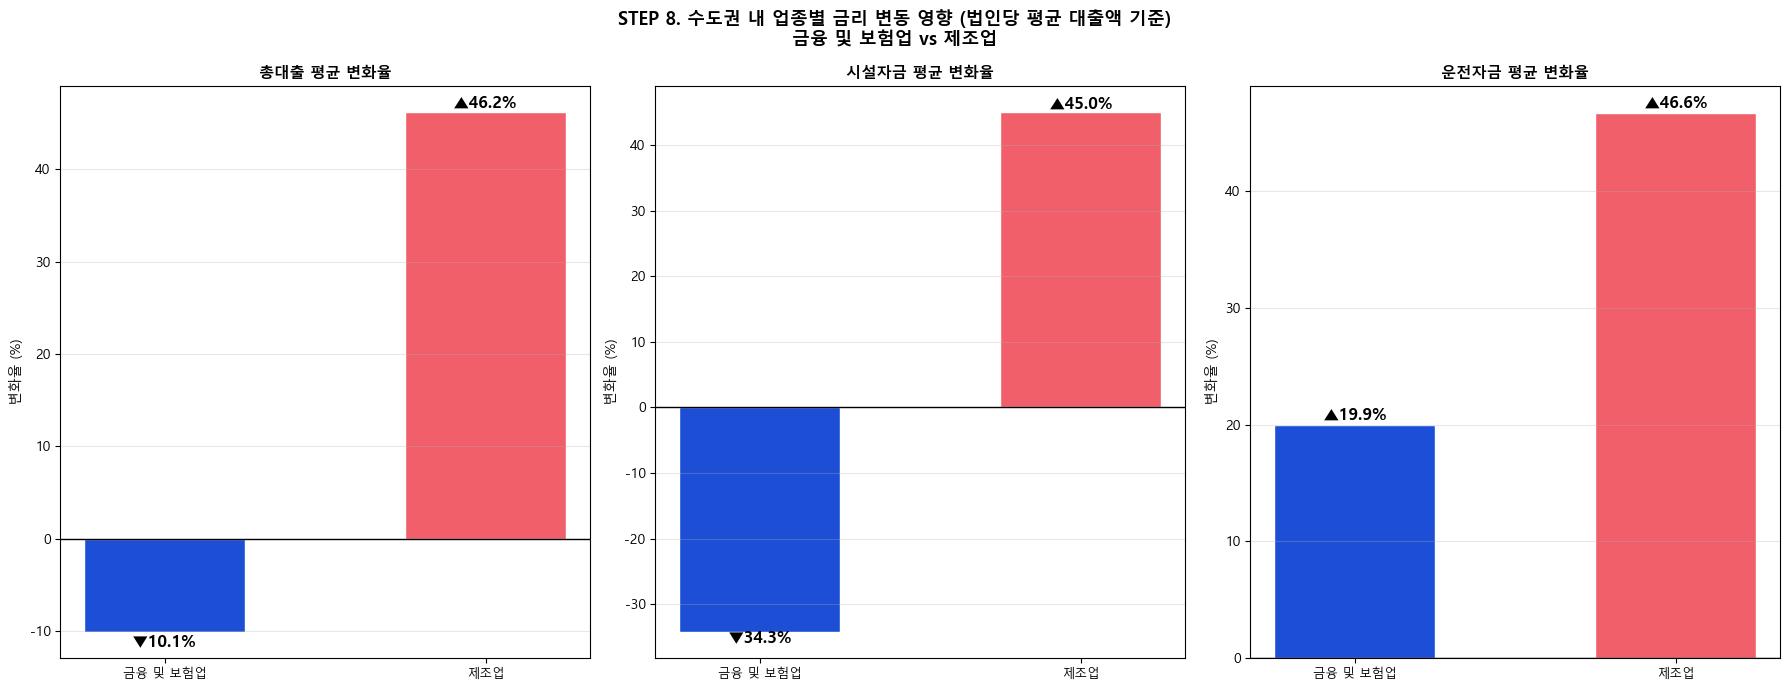

In [5]:
# ══════════════════════════════════════════════════════
# 1. 업종별/월별 평균 데이터 집계 (원본 데이터 df_2r 활용)
# ══════════════════════════════════════════════════════
# 수도권 데이터만 필터링
df_metro = df_2r[df_2r['지역구분'] == '수도권'].copy()

# 업종별/월별/금리구분별 평균(법인당) 집계
# 업종_대분류 컬럼명은 데이터셋에 맞게 확인이 필요합니다 (예: '업종_대분류')
ind_avg = df_metro.groupby(['기준년월_dt', '업종_대분류', '금리구분']).agg({
    '총대출잔액': 'mean',
    '여신_시설자금대출잔액': 'mean',
    '여신_운전자금대출잔액': 'mean'
}).reset_index()

# 분석 대상 업종 필터링 (금융 및 보험업, 제조업)
target_inds = ['금융 및 보험업', '제조업']
ind_avg = ind_avg[ind_avg['업종_대분류'].isin(target_inds)]

# ══════════════════════════════════════════════════════
# 2. 금리 시점별 변화율 산출 (저금리 vs 고금리 평균 비교)
# ══════════════════════════════════════════════════════
view_data = []

for ind in target_inds:
    # 해당 업종의 저금리(1.25%) 평균과 고금리(3.50%) 평균 추출
    low_period = ind_avg[(ind_avg['업종_대분류'] == ind) & (ind_avg['금리구분'] == '저금리(1.25%)')]
    high_period = ind_avg[(ind_avg['업종_대분류'] == ind) & (ind_avg['금리구분'] == '고금리(3.50%)')]
    
    if not low_period.empty and not high_period.empty:
        # 시점별 평균값 (각 기간의 월평균의 평균)
        v0_total = low_period['총대출잔액'].mean()
        v1_total = high_period['총대출잔액'].mean()
        
        v0_facility = low_period['여신_시설자금대출잔액'].mean()
        v1_facility = high_period['여신_시설자금대출잔액'].mean()
        
        v0_working = low_period['여신_운전자금대출잔액'].mean()
        v1_working = high_period['여신_운전자금대출잔액'].mean()
        
        # 변화율 계산 ((나중-처음)/처음 * 100)
        view_data.append({'업종': ind, '구분': '총대출', '변화율': (v1_total - v0_total) / v0_total * 100})
        view_data.append({'업종': ind, '구분': '시설자금', '변화율': (v1_facility - v0_facility) / v0_facility * 100})
        view_data.append({'업종': ind, '구분': '운전자금', '변화율': (v1_working - v0_working) / v0_working * 100})

df_ind_avg = pd.DataFrame(view_data)

# ══════════════════════════════════════════════════════
# 3. 시각화 (원본 그래프 코드 구조 유지)
# ══════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle(
    'STEP 8. 수도권 내 업종별 금리 변동 영향 (법인당 평균 대출액 기준)\n'
    '금융 및 보험업 vs 제조업',
    fontsize=13, fontweight='bold'
)

ind_colors = {'금융 및 보험업': '#1c4fd6', '제조업': '#f05f6a'}

for ax, label in zip(axes, ['총대출', '시설자금', '운전자금']):
    # 평균 기준 데이터 사용
    sub = df_ind_avg[df_ind_avg['구분'] == label]
    if len(sub) == 0: continue

    inds = sub['업종'].tolist()
    변화율s = sub['변화율'].tolist()
    colors = [ind_colors.get(i, '#aaaaaa') for i in inds]

    bars = ax.bar(inds, 변화율s, color=colors, edgecolor='white', width=0.5)
    
    for bar, val in zip(bars, 변화율s):
        방향 = '▲' if val >= 0 else '▼'
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + (0.5 if val >= 0 else -1.5), # 텍스트 위치 미세 조정
                f'{방향}{abs(val):.1f}%',
                ha='center', fontsize=12, fontweight='bold')

    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(f'{label} 평균 변화율', fontsize=11, fontweight='bold')
    ax.set_ylabel('변화율 (%)')
    ax.set_xticklabels(inds, fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
df['업종_대분류'].value_counts()

업종_대분류
제조업                         121214
도매 및 소매업                     65623
건설업                          51258
부동산업                         31749
운수 및 창고업                     12798
사업시설 관리, 사업 지원 및 임대 서비스업     11820
전문, 과학 및 기술 서비스업              9388
숙박 및 음식점업                     8082
정보통신업                         7385
협회 및 단체, 수리 및 기타 개인 서비스업      7101
교육 서비스업                       4353
수도, 하수 및 폐기물 처리, 원료 재생업       4331
예술, 스포츠 및 여가관련 서비스업           3651
금융 및 보험업                      3281
보건업 및 사회복지 서비스업               1810
전기, 가스, 증기 및 공기조절 공급업         1776
농업, 임업 및 어업                   1195
광업                             484
Name: count, dtype: int64

In [ ]:
df.columns

Index(['기준년월', '업종_대분류', '업종_중분류', '사업장_시도', '사업장_시군구', '법인_고객등급', '전담고객여부',
       '요구불예금잔액', '거치식예금잔액', '적립식예금잔액', '수익증권잔액', '신탁잔액', '퇴직연금잔액', '여신한도금액',
       '여신_운전자금대출잔액', '여신_시설자금대출잔액', '외환_수출실적금액', '외환_수입실적금액', '신용카드사용금액',
       '체크카드사용금액', '창구거래금액', '인터넷뱅킹거래금액', '스마트뱅킹거래금액', '폰뱅킹거래금액', 'ATM거래금액',
       '자동이체금액', '요구불입금금액', '요구불출금금액', '요구불예금좌수', '거치식예금좌수', '적립식예금좌수',
       '수익증권좌수', '신탁좌수', '퇴직연금좌수', '여신_운전자금대출좌수', '여신_시설자금대출좌수', '신용카드개수',
       '외환_수출실적거래건수', '외환_수입실적거래건수', '창구거래건수', '인터넷뱅킹거래건수', '스마트뱅킹거래건수',
       '폰뱅킹거래건수', 'ATM거래건수', '자동이체거래건수', '기준년월_dt', '총대출잔액', '지역구분', '기준금리',
       '금리구분'],
      dtype='object')

In [ ]:
# ==========================================
# STEP 3. 수도권 t-test (핵심)
# ==========================================

metro = monthly_clean[monthly_clean['지역구분']=='수도권']

low = metro[metro['기준금리']==1.25]['법인당']
high = metro[metro['기준금리']==3.50]['법인당']

# 기본 통계
x1, x2 = low.mean(), high.mean()
s1, s2 = low.std(ddof=1), high.std(ddof=1)
n1, n2 = len(low), len(high)

# 수식 기반 계산
SE = np.sqrt((s1**2/n1) + (s2**2/n2))
t_manual = (x2 - x1) / SE

# scipy
t_stat, p_val = stats.ttest_ind(high, low, equal_var=False)

print("\n===== 수도권 t-test =====")
print(f"저금리 평균: {x1:,.0f}")
print(f"고금리 평균: {x2:,.0f}")
print(f"변화율: {(x2-x1)/x1*100:.2f}%")

print("\n[수식]")
print("t = (x2 - x1) / √(s1²/n1 + s2²/n2)")
print(f"t = {t_manual:.4f}")

print("\n[p-value]")
print(f"p = {p_val:.6f}")

if p_val < 0.05:
    print("👉 H₀ 기각 → 수도권 민감도 유의미")
else:
    print("👉 H₀ 채택 → 유의하지 않음")


===== 수도권 t-test =====
저금리 평균: 1,039
고금리 평균: 1,234
변화율: 18.80%

[수식]
t = (x2 - x1) / √(s1²/n1 + s2²/n2)
t = 8.2600

[p-value]
p = 0.000152
👉 H₀ 기각 → 수도권 민감도 유의미


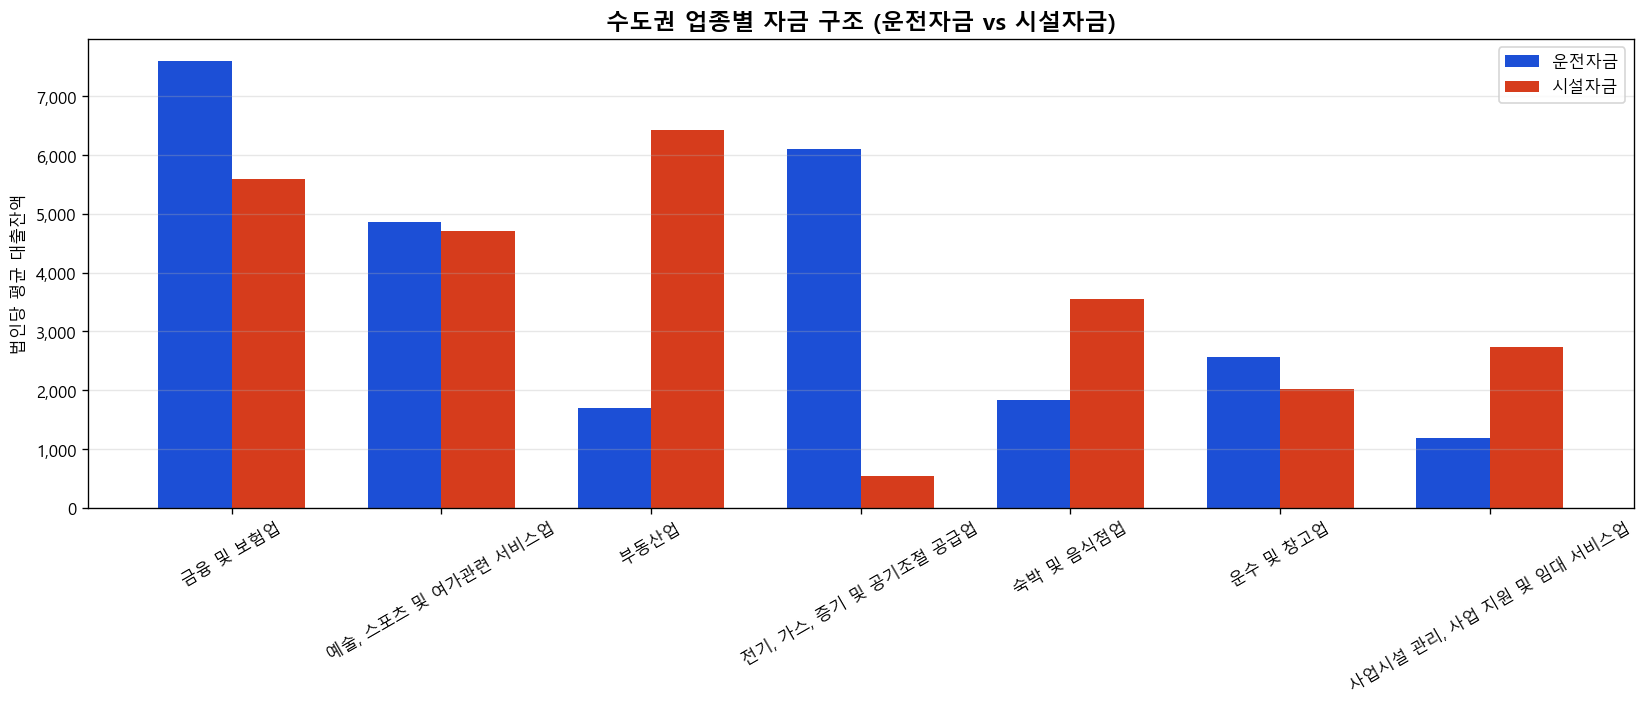

In [ ]:
# ==========================================
# 1. 월별 + 업종별 (운전 / 시설 분리)
# ==========================================
monthly_fund = metro.groupby(
    ['기준년월_dt','업종_대분류']
).agg(
    운전자금=('여신_운전자금대출잔액','sum'),
    시설자금=('여신_시설자금대출잔액','sum'),
    법인수=('총대출잔액','count')
).reset_index()

monthly_fund['운전자금_법인당'] = monthly_fund['운전자금'] / monthly_fund['법인수']
monthly_fund['시설자금_법인당'] = monthly_fund['시설자금'] / monthly_fund['법인수']

# ==========================================
# 2. 업종별 평균
# ==========================================
fund_avg = monthly_fund.groupby('업종_대분류').agg(
    운전자금=('운전자금_법인당','mean'),
    시설자금=('시설자금_법인당','mean')
)

# 총합 기준 정렬
fund_avg['총합'] = fund_avg['운전자금'] + fund_avg['시설자금']
fund_avg = fund_avg.sort_values(by='총합', ascending=False)

top7 = fund_avg.head(7)

# ==========================================
# 3. 시각화 (이중 막대)
# ==========================================
plt.figure(figsize=(14,6))

x = np.arange(len(top7))
width = 0.35

plt.bar(x - width/2, top7['운전자금'], width,
        label='운전자금', color='#1c4fd6')

plt.bar(x + width/2, top7['시설자금'], width,
        label='시설자금', color='#d63c1c')

plt.xticks(x, top7.index, rotation=30)
plt.title('수도권 업종별 자금 구조 (운전자금 vs 시설자금)', fontsize=14, fontweight='bold')
plt.ylabel('법인당 평균 대출잔액')

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'{x:,.0f}')
)

plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mticker

# ==========================================
# 1. 수도권 필터링
# ==========================================
metro = df[df['지역구분'] == '수도권'].copy()

metro['총대출잔액'] = (
    metro['여신_운전자금대출잔액'].fillna(0) +
    metro['여신_시설자금대출잔액'].fillna(0)
)

# ==========================================
# 2. 월별 + 업종별 집계 (시계열 반영)
# ==========================================
monthly_ind = metro.groupby(
    ['기준년월_dt','업종_대분류']
).agg(
    총대출=('총대출잔액','sum'),
    법인수=('총대출잔액','count')
).reset_index()

monthly_ind['법인당'] = monthly_ind['총대출'] / monthly_ind['법인수']

# ==========================================
# 3. 고금리 구간 필터
# ==========================================
high_period = monthly_ind[
    (monthly_ind['기준년월_dt'] >= '2023-01-01') &
    (monthly_ind['기준년월_dt'] <= '2024-01-31')
]

# ==========================================
# 4. 업종별 평균 (핵심)
# ==========================================
industry_high_avg = (
    high_period.groupby('업종_대분류')['법인당']
    .mean()
    .sort_values(ascending=False)
)

top10 = industry_high_avg.head(10)

print("\n===== 고금리 구간 업종별 평균 대출 =====")
print(top10)


===== 고금리 구간 업종별 평균 대출 =====
업종_대분류
금융 및 보험업                    12106.365091
예술, 스포츠 및 여가관련 서비스업         10496.107143
전기, 가스, 증기 및 공기조절 공급업        8703.025641
부동산업                         7859.587146
숙박 및 음식점업                    5706.469500
운수 및 창고업                     4633.014870
사업시설 관리, 사업 지원 및 임대 서비스업     4053.429975
건설업                          3628.482680
제조업                          2606.776416
교육 서비스업                      2276.392691
Name: 법인당, dtype: float64


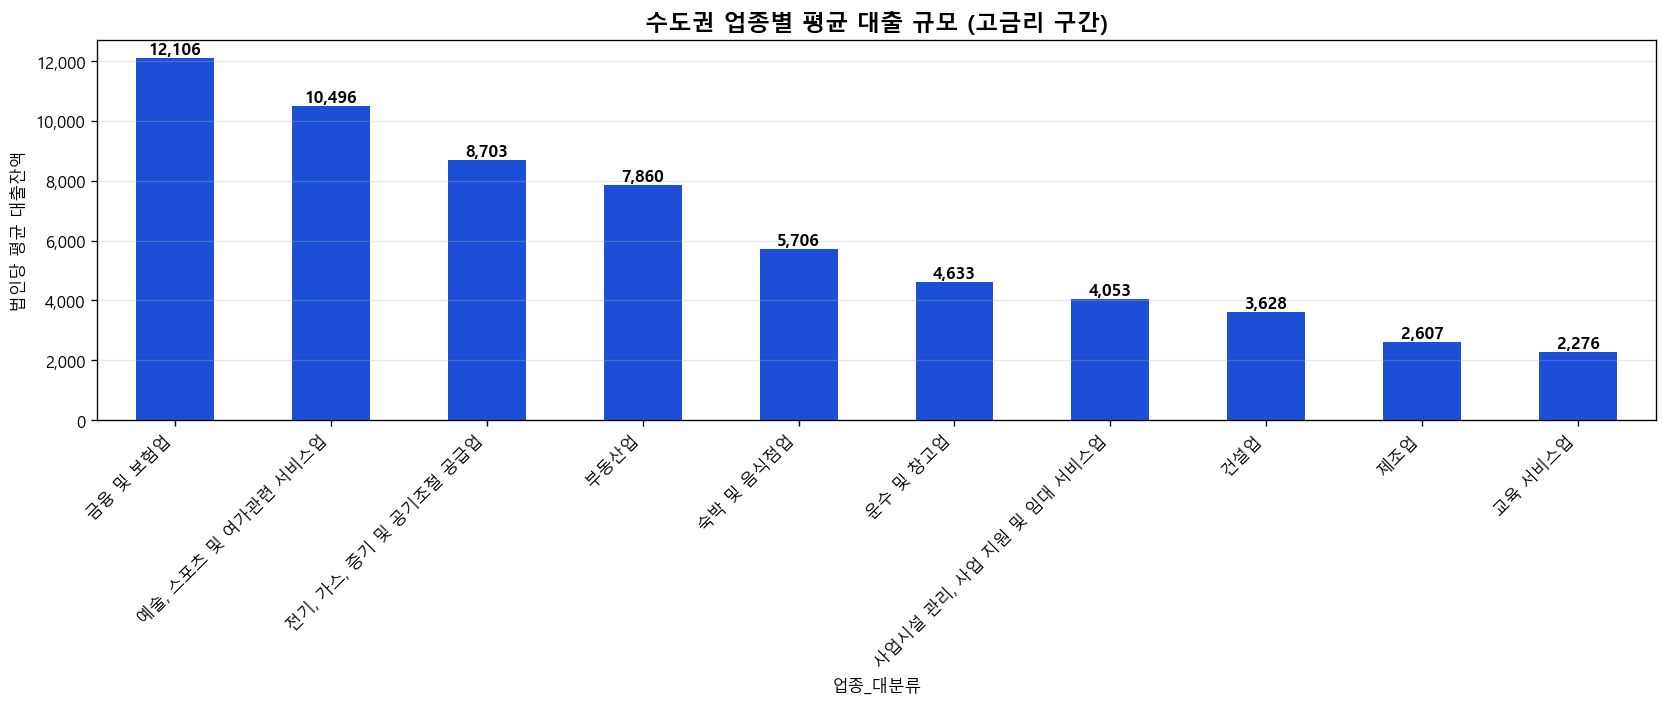

In [ ]:
plt.figure(figsize=(14,6))

bars = top10.plot(kind='bar', color='#1c4fd6')

# 값 표시
for i, v in enumerate(top10.values):
    plt.text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('수도권 업종별 평균 대출 규모 (고금리 구간)', fontsize=14, fontweight='bold')
plt.ylabel('법인당 평균 대출잔액')
plt.xticks(rotation=45, ha='right')

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'{x:,.0f}')
)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

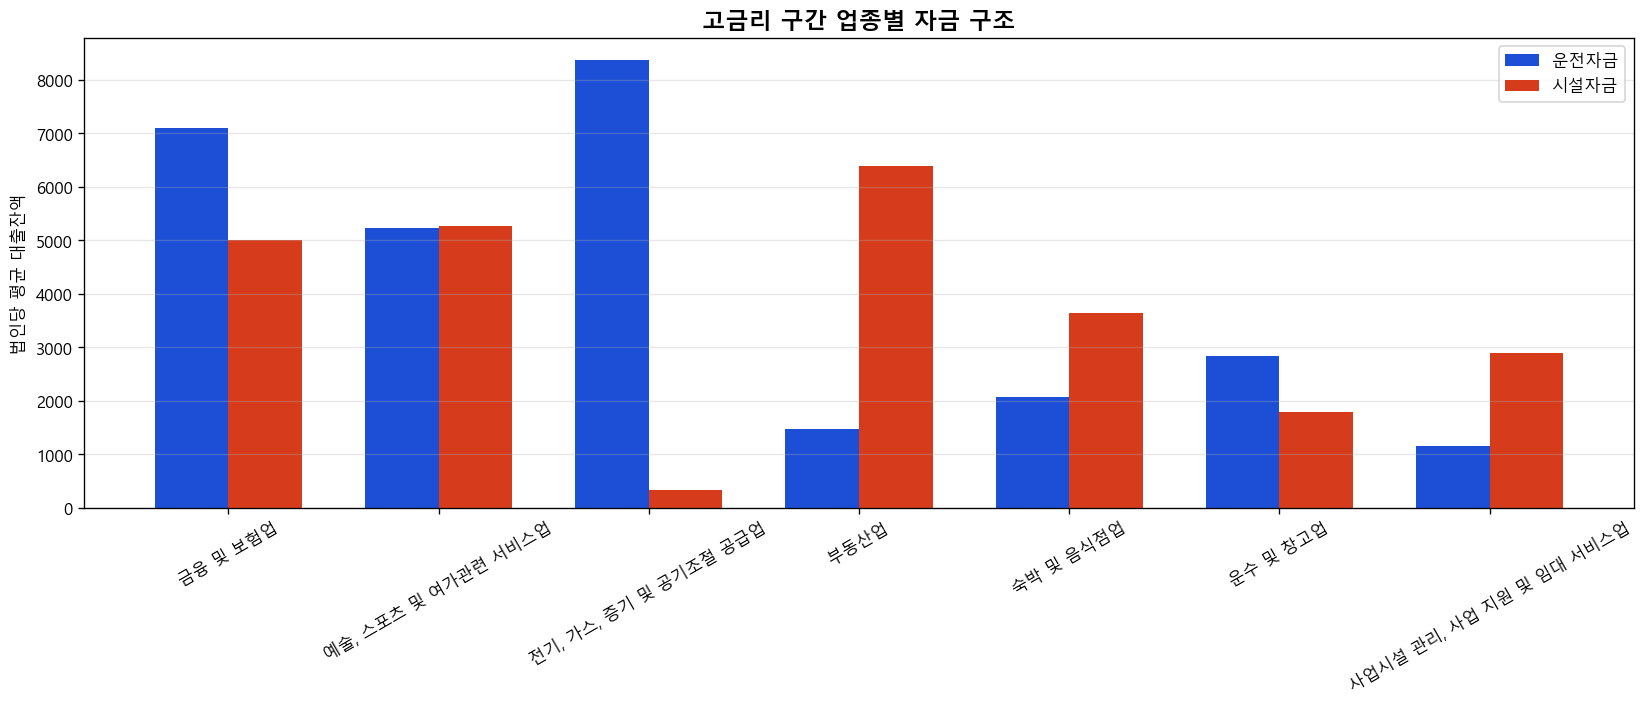

In [ ]:
monthly_fund = metro.groupby(
    ['기준년월_dt','업종_대분류']
).agg(
    운전자금=('여신_운전자금대출잔액','sum'),
    시설자금=('여신_시설자금대출잔액','sum'),
    법인수=('총대출잔액','count')
).reset_index()

monthly_fund['운전자금'] = monthly_fund['운전자금'] / monthly_fund['법인수']
monthly_fund['시설자금'] = monthly_fund['시설자금'] / monthly_fund['법인수']

high_fund = monthly_fund[
    (monthly_fund['기준년월_dt'] >= '2023-01-01') &
    (monthly_fund['기준년월_dt'] <= '2024-01-31')
]

fund_avg = high_fund.groupby('업종_대분류')[['운전자금','시설자금']].mean()
fund_avg['총합'] = fund_avg.sum(axis=1)

top7 = fund_avg.sort_values(by='총합', ascending=False).head(7)

# 그래프
plt.figure(figsize=(14,6))

x = np.arange(len(top7))
w = 0.35

plt.bar(x-w/2, top7['운전자금'], w, label='운전자금', color='#1c4fd6')
plt.bar(x+w/2, top7['시설자금'], w, label='시설자금', color='#d63c1c')

plt.xticks(x, top7.index, rotation=30)
plt.title('고금리 구간 업종별 자금 구조', fontsize=14, fontweight='bold')
plt.ylabel('법인당 평균 대출잔액')

plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

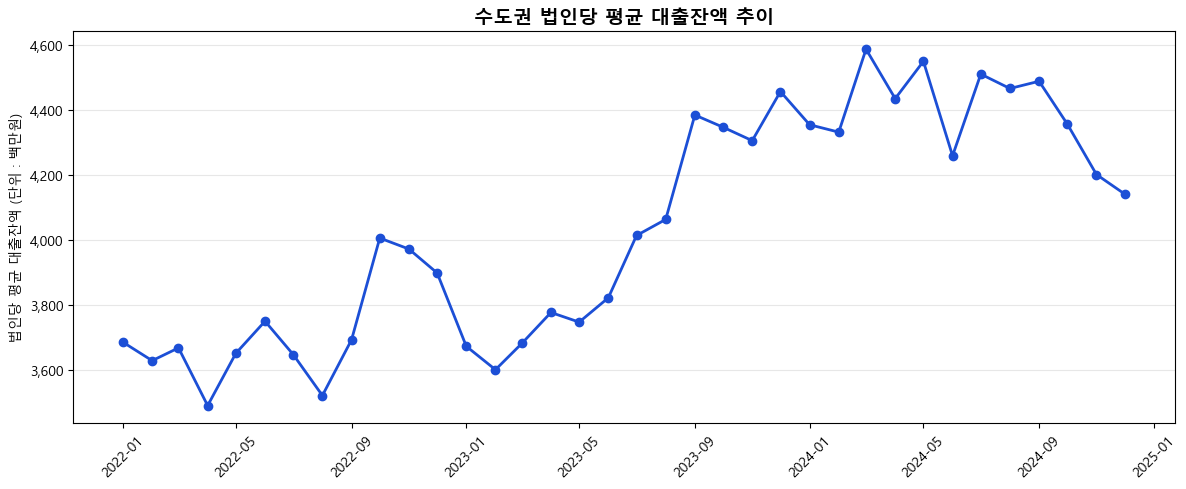

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ==========================================
# 수도권 데이터
# ==========================================
metro = df[df['사업장_시도'].isin(['서울특별시','경기도','인천광역시'])].copy()

metro['총대출잔액'] = (
    metro['여신_운전자금대출잔액'].fillna(0) +
    metro['여신_시설자금대출잔액'].fillna(0)
)

metro['기준년월_dt'] = pd.to_datetime(metro['기준년월'].astype(str), format='%Y%m')

# ==========================================
# 월별 법인당 평균
# ==========================================
metro_monthly = metro.groupby('기준년월_dt').agg(
    총대출=('총대출잔액','sum'),
    법인수=('총대출잔액','count')
).reset_index()

metro_monthly['법인당'] = metro_monthly['총대출'] / metro_monthly['법인수']

# ==========================================
# 시계열 그래프
# ==========================================
plt.figure(figsize=(12,5))

plt.plot(metro_monthly['기준년월_dt'], metro_monthly['법인당'],
         marker='o', linewidth=2, color='#1c4fd6')

plt.title('수도권 법인당 평균 대출잔액 추이', fontsize=14, fontweight='bold')
plt.ylabel('법인당 평균 대출잔액 (단위 : 백만원)')

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'{x:,.0f}')
)

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

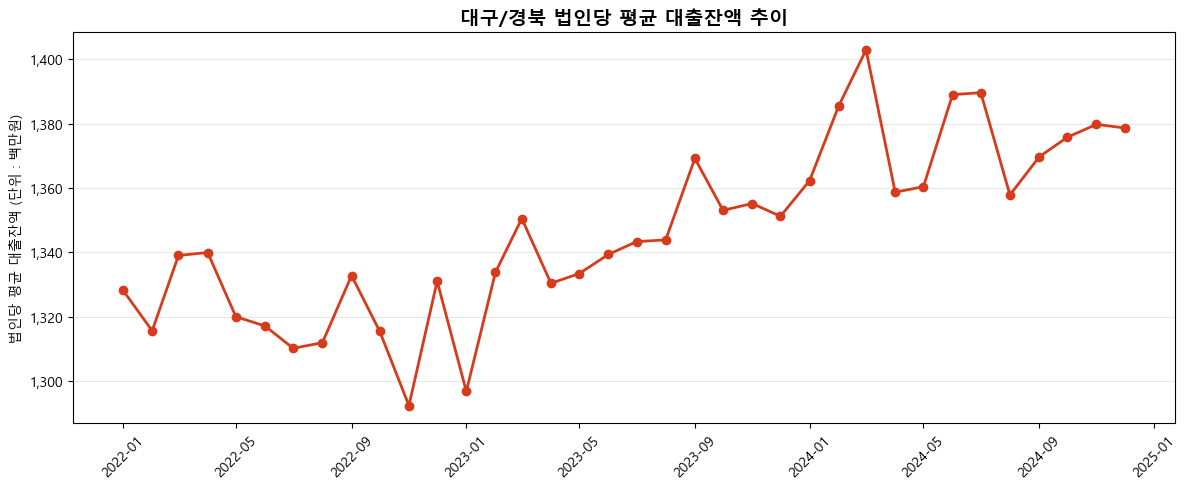

In [11]:
# ==========================================
# 대구경북 데이터
# ==========================================
daegu = df[df['사업장_시도'].isin(['대구광역시','경상북도'])].copy()

daegu['총대출잔액'] = (
    daegu['여신_운전자금대출잔액'].fillna(0) +
    daegu['여신_시설자금대출잔액'].fillna(0)
)

daegu['기준년월_dt'] = pd.to_datetime(daegu['기준년월'].astype(str), format='%Y%m')

# ==========================================
# 월별 법인당 평균
# ==========================================
daegu_monthly = daegu.groupby('기준년월_dt').agg(
    총대출=('총대출잔액','sum'),
    법인수=('총대출잔액','count')
).reset_index()

daegu_monthly['법인당'] = daegu_monthly['총대출'] / daegu_monthly['법인수']

# ==========================================
# 시계열 그래프
# ==========================================
plt.figure(figsize=(12,5))

plt.plot(daegu_monthly['기준년월_dt'], daegu_monthly['법인당'],
         marker='o', linewidth=2, color='#d63c1c')

plt.title('대구/경북 법인당 평균 대출잔액 추이', fontsize=14, fontweight='bold')
plt.ylabel('법인당 평균 대출잔액 (단위 : 백만원)')

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'{x:,.0f}')
)

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats

# ==========================================
# 1. 총대출 생성
# ==========================================
df['총대출잔액'] = (
    df['여신_운전자금대출잔액'].fillna(0) +
    df['여신_시설자금대출잔액'].fillna(0)
)

# ==========================================
# 2. 지역별 분리
# ==========================================
metro = df[df['지역구분']=='수도권'].copy()
daegu = df[df['지역구분']=='대구/경북'].copy()

# ==========================================
# 3. 월별 법인당 평균 (함수화 ⭐)
# ==========================================
def make_monthly(data):
    m = data.groupby('기준년월_dt').agg(
        총대출=('총대출잔액','sum'),
        법인수=('총대출잔액','count')
    ).reset_index()
    
    m['법인당'] = m['총대출'] / m['법인수']
    return m

metro_m = make_monthly(metro)
daegu_m = make_monthly(daegu)

# ==========================================
# 4. 금리 구간 분리
# ==========================================
def split_period(data):
    low = data[
        (data['기준년월_dt'] >= '2022-01-01') &
        (data['기준년월_dt'] <= '2022-03-31')
    ]['법인당']
    
    high = data[
        (data['기준년월_dt'] >= '2023-01-01') &
        (data['기준년월_dt'] <= '2024-01-31')
    ]['법인당']
    
    return low, high

metro_low, metro_high = split_period(metro_m)
daegu_low, daegu_high = split_period(daegu_m)

# ==========================================
# 5. t-test (Welch)
# ==========================================
metro_t, metro_p = stats.ttest_ind(
    metro_high, metro_low, equal_var=False
)

daegu_t, daegu_p = stats.ttest_ind(
    daegu_high, daegu_low, equal_var=False
)

# ==========================================
# 6. 결과 출력
# ==========================================
def summary(name, low, high, t, p):
    change = (high.mean() - low.mean()) / low.mean() * 100
    print(f"\n[{name}]")
    print(f"저금리 평균: {low.mean():,.0f}")
    print(f"고금리 평균: {high.mean():,.0f}")
    print(f"변화율: {change:+.2f}%")
    print(f"t값: {t:.4f}")
    print(f"p값: {p:.4f}")
    
summary("수도권", metro_low, metro_high, metro_t, metro_p)
summary("대구경북", daegu_low, daegu_high, daegu_t, daegu_p)


[수도권]
저금리 평균: 3,660
고금리 평균: 4,017
변화율: +9.75%
t값: 3.9807
p값: 0.0016

[대구경북]
저금리 평균: 1,328
고금리 평균: 1,343
변화율: +1.18%
t값: 1.8570
p값: 0.1279


In [ ]:
# ==========================================
# 수도권 t-test 입력 데이터 확인
# ==========================================
print("\n===== 수도권 t-test 입력 데이터 =====")

print("\n[저금리 구간 데이터]")
print(metro_low)

print("\n[고금리 구간 데이터]")
print(metro_high)

# ==========================================
# 대구경북 t-test 입력 데이터 확인
# ==========================================
print("\n===== 대구경북 t-test 입력 데이터 =====")

print("\n[저금리 구간 데이터]")
print(daegu_low)

print("\n[고금리 구간 데이터]")
print(daegu_high)


===== 수도권 t-test 입력 데이터 =====

[저금리 구간 데이터]
0    3684.691085
1    3627.965751
2    3667.277728
Name: 법인당, dtype: float64

[고금리 구간 데이터]
12    3672.142317
13    3600.125588
14    3680.817966
15    3776.269462
16    3746.596766
17    3821.438443
18    4013.186408
19    4062.617735
20    4384.024707
21    4346.455969
22    4305.089387
23    4456.280641
24    4354.042421
Name: 법인당, dtype: float64

===== 대구경북 t-test 입력 데이터 =====

[저금리 구간 데이터]
0    1328.240702
1    1315.663632
2    1339.082286
Name: 법인당, dtype: float64

[고금리 구간 데이터]
12    1296.809891
13    1333.841435
14    1350.552931
15    1330.418307
16    1333.442036
17    1339.379569
18    1343.371040
19    1343.922386
20    1369.240875
21    1353.098188
22    1355.222820
23    1351.252387
24    1362.339851
Name: 법인당, dtype: float64


In [ ]:
print("\n===== t-test 사용 컬럼 =====")
print("사용 변수: 법인당 평균 대출잔액")
print("생성 방식:")
print("총대출잔액 = 여신_운전자금대출잔액 + 여신_시설자금대출잔액")
print("법인당 평균 = 총대출잔액 / 법인수")
print("기준: 기준년월 기준 월별 집계")
print("검정 방식: 월별 평균값을 표본으로 사용하여")
print("저금리 구간 vs 고금리 구간 간 차이를 t-test로 검증")


===== t-test 사용 컬럼 =====
사용 변수: 법인당 평균 대출잔액
생성 방식:
총대출잔액 = 여신_운전자금대출잔액 + 여신_시설자금대출잔액
법인당 평균 = 총대출잔액 / 법인수
기준: 기준년월 기준 월별 집계
검정 방식: 월별 평균값을 표본으로 사용하여
저금리 구간 vs 고금리 구간 간 차이를 t-test로 검증


In [ ]:
df.columns

Index(['기준년월', '업종_대분류', '업종_중분류', '사업장_시도', '사업장_시군구', '법인_고객등급', '전담고객여부',
       '요구불예금잔액', '거치식예금잔액', '적립식예금잔액', '수익증권잔액', '신탁잔액', '퇴직연금잔액', '여신한도금액',
       '여신_운전자금대출잔액', '여신_시설자금대출잔액', '외환_수출실적금액', '외환_수입실적금액', '신용카드사용금액',
       '체크카드사용금액', '창구거래금액', '인터넷뱅킹거래금액', '스마트뱅킹거래금액', '폰뱅킹거래금액', 'ATM거래금액',
       '자동이체금액', '요구불입금금액', '요구불출금금액', '요구불예금좌수', '거치식예금좌수', '적립식예금좌수',
       '수익증권좌수', '신탁좌수', '퇴직연금좌수', '여신_운전자금대출좌수', '여신_시설자금대출좌수', '신용카드개수',
       '외환_수출실적거래건수', '외환_수입실적거래건수', '창구거래건수', '인터넷뱅킹거래건수', '스마트뱅킹거래건수',
       '폰뱅킹거래건수', 'ATM거래건수', '자동이체거래건수', '기준년월_dt', '총대출잔액', '지역구분', '기준금리',
       '금리구분'],
      dtype='object')

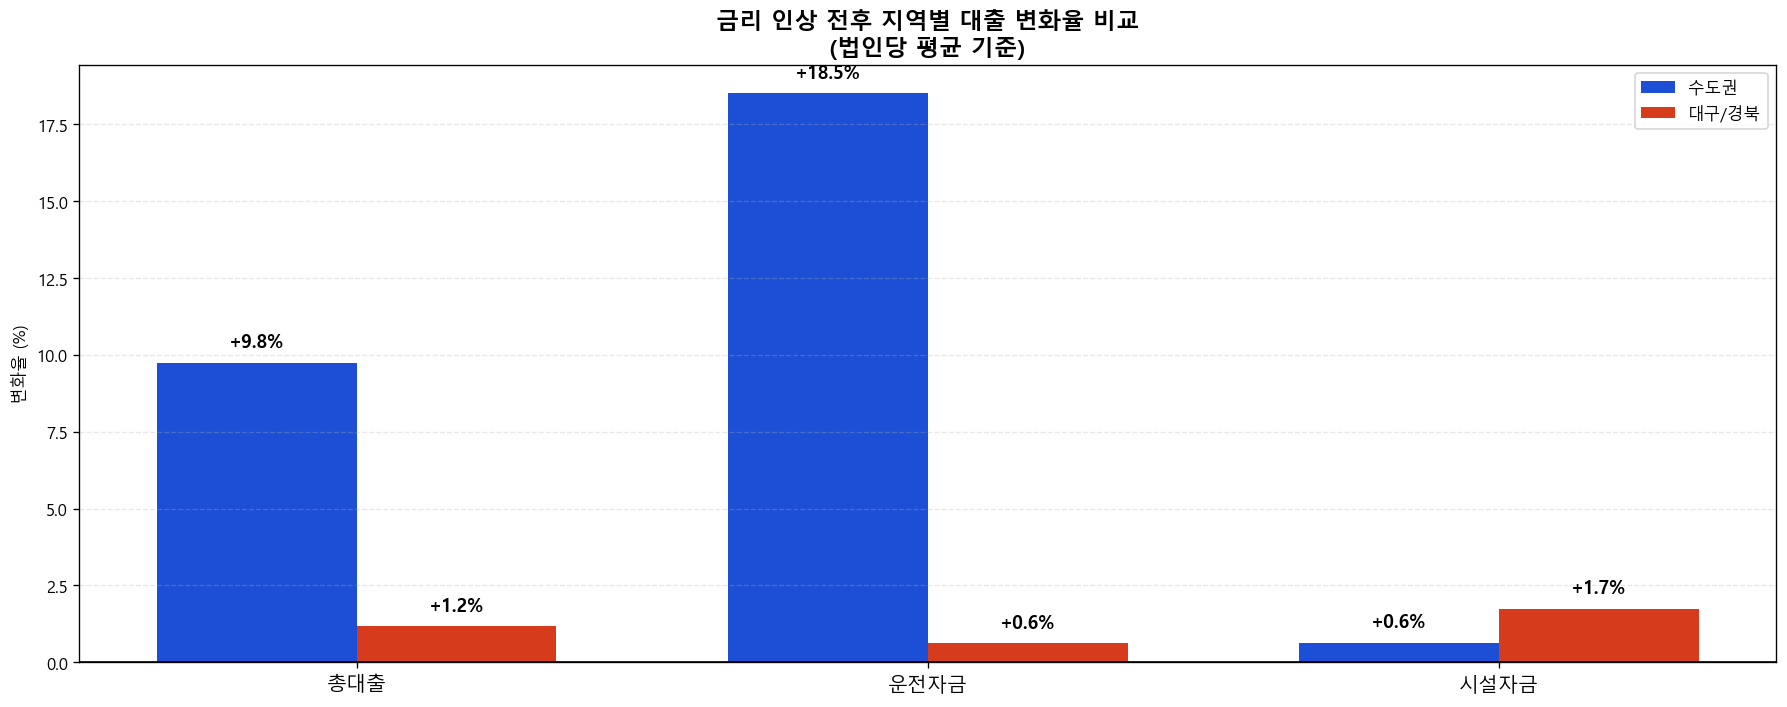

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 총대출 생성
# ==========================================
df['총대출잔액'] = (
    df['여신_운전자금대출잔액'].fillna(0) +
    df['여신_시설자금대출잔액'].fillna(0)
)

# ==========================================
# 2. 지역 분리
# ==========================================
metro = df[df['지역구분']=='수도권'].copy()
daegu = df[df['지역구분']=='대구/경북'].copy()

# ==========================================
# 3. 월별 법인당 평균 함수
# ==========================================
def make_monthly(data):
    m = data.groupby('기준년월').agg(
        총대출=('총대출잔액','sum'),
        운전자금=('여신_운전자금대출잔액','sum'),
        시설자금=('여신_시설자금대출잔액','sum'),
        법인수=('총대출잔액','count')
    ).reset_index()
    
    m['총대출_법인당'] = m['총대출'] / m['법인수']
    m['운전자금_법인당'] = m['운전자금'] / m['법인수']
    m['시설자금_법인당'] = m['시설자금'] / m['법인수']
    
    return m

metro_m = make_monthly(metro)
daegu_m = make_monthly(daegu)

# ==========================================
# 4. 구간 분리 함수
# ==========================================
def get_change(data, col):
    low = data[
        (data['기준년월'] >= 202201) &
        (data['기준년월'] <= 202203)
    ][col]
    
    high = data[
        (data['기준년월'] >= 202301) &
        (data['기준년월'] <= 202401)
    ][col]
    
    change = (high.mean() - low.mean()) / low.mean() * 100
    return change

# ==========================================
# 5. 변화율 계산
# ==========================================
labels = ['총대출', '운전자금', '시설자금']

metro_changes = [
    get_change(metro_m, '총대출_법인당'),
    get_change(metro_m, '운전자금_법인당'),
    get_change(metro_m, '시설자금_법인당')
]

daegu_changes = [
    get_change(daegu_m, '총대출_법인당'),
    get_change(daegu_m, '운전자금_법인당'),
    get_change(daegu_m, '시설자금_법인당')
]

# ==========================================
# 6. 시각화
# ==========================================
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(15,6))

bars1 = ax.bar(x - width/2, metro_changes, width,
               label='수도권', color='#1c4fd6')

bars2 = ax.bar(x + width/2, daegu_changes, width,
               label='대구/경북', color='#d63c1c')

# 값 표시
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        sign = '+' if height >= 0 else ''
        ax.text(bar.get_x() + bar.get_width()/2,
                height + 0.5,
                f'{sign}{height:.1f}%',
                ha='center', fontsize=11, fontweight='bold')

# 디자인
ax.set_title('금리 인상 전후 지역별 대출 변화율 비교\n(법인당 평균 기준)',
             fontsize=14, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)

ax.set_ylabel('변화율 (%)')
ax.axhline(0, color='black', linewidth=1)

ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 수도권 데이터
# ==========================================
sudo = df[df['지역구분']=='수도권'].copy()

sudo['총대출잔액'] = (
    sudo['여신_운전자금대출잔액'].fillna(0) +
    sudo['여신_시설자금대출잔액'].fillna(0)
)

# ==========================================
# 월별 업종 집계
# ==========================================
monthly_ind = sudo.groupby(['기준년월','업종_대분류']).agg(
    총대출=('총대출잔액','sum'),
    법인수=('총대출잔액','count')
).reset_index()

monthly_ind['법인당'] = monthly_ind['총대출'] / monthly_ind['법인수']

# ==========================================
# 금리 구간 나누기
# ==========================================
low = monthly_ind[
    (monthly_ind['기준년월']>=202201) &
    (monthly_ind['기준년월']<=202203)
]

high = monthly_ind[
    (monthly_ind['기준년월']>=202301) &
    (monthly_ind['기준년월']<=202401)
]

# ==========================================
# 업종별 평균
# ==========================================
low_avg = low.groupby('업종_대분류')['법인당'].mean()
high_avg = high.groupby('업종_대분류')['법인당'].mean()

compare = pd.concat([low_avg, high_avg], axis=1)
compare.columns = ['저금리','고금리']

# ==========================================
# 핵심 지표
# ==========================================
compare['증가금액'] = compare['고금리'] - compare['저금리']
compare['변화율'] = (compare['증가금액'] / compare['저금리']) * 100

# ==========================================
# “가치 점수” (핵심🔥)
# ==========================================
compare['가치점수'] = (
    compare['고금리'] * 0.5 +      # 규모
    compare['증가금액'] * 0.3 +    # 성장
    compare['변화율'] * 0.2        # 민감도
)

compare = compare.sort_values(by='가치점수', ascending=False)

print(compare.head(10))

                                   저금리           고금리         증가금액         변화율  \
업종_대분류                                                                          
금융 및 보험업                  14306.920996  12106.365091 -2200.555905  -15.381059   
예술, 스포츠 및 여가관련 서비스업       10639.206349  10496.107143  -143.099206   -1.345018   
전기, 가스, 증기 및 공기조절 공급업      9216.500000   8703.025641  -513.474359   -5.571251   
부동산업                       7724.712987   7859.587146   134.874160    1.746009   
숙박 및 음식점업                  4802.484848   5706.469500   903.984651   18.823269   
운수 및 창고업                   3356.230316   4633.014870  1276.784555   38.042221   
사업시설 관리, 사업 지원 및 임대 서비스업   3634.225275   4053.429975   419.204700   11.534912   
건설업                        2829.517021   3628.482680   798.965660   28.236821   
수도, 하수 및 폐기물 처리, 원료 재생업     300.333333   2240.466117  1940.132784  645.993158   
제조업                        1855.989939   2606.776416   750.786477   40.452077   

                           

In [ ]:
# 증가/감소 분리
increase = compare[compare['증가금액'] > 0]
decrease = compare[compare['증가금액'] <= 0]

print("📈 성장 업종 TOP5")
print(increase.sort_values(by='증가금액', ascending=False).head())

print("\n📉 감소 업종 TOP5")
print(decrease.sort_values(by='증가금액').head())

📈 성장 업종 TOP5
                                 저금리          고금리         증가금액         변화율  \
업종_대분류                                                                       
수도, 하수 및 폐기물 처리, 원료 재생업   300.333333  2240.466117  1940.132784  645.993158   
운수 및 창고업                 3356.230316  4633.014870  1276.784555   38.042221   
전문, 과학 및 기술 서비스업          823.681481  1957.924049  1134.242568  137.704027   
숙박 및 음식점업                4802.484848  5706.469500   903.984651   18.823269   
건설업                      2829.517021  3628.482680   798.965660   28.236821   

                                가치점수  
업종_대분류                                
수도, 하수 및 폐기물 처리, 원료 재생업  1831.471525  
운수 및 창고업                 2707.151246  
전문, 과학 및 기술 서비스업         1346.775600  
숙박 및 음식점업                3128.194799  
건설업                      2059.578402  

📉 감소 업종 TOP5
                                   저금리           고금리         증가금액        변화율  \
업종_대분류                                                                   

In [ ]:
# ==========================================
# 수도권 데이터
# ==========================================
metro = df[df['지역구분']=='수도권'].copy()

# 총대출
metro['총대출잔액'] = (
    metro['여신_운전자금대출잔액'] +
    metro['여신_시설자금대출잔액']
)

# 날짜
metro['기준년월_dt'] = pd.to_datetime(metro['기준년월'].astype(str), format='%Y%m')

# ==========================================
# 월별 업종별 법인당
# ==========================================
monthly_industry = metro.groupby(['기준년월_dt','업종_대분류']).agg(
    총대출=('총대출잔액','sum'),
    법인수=('총대출잔액','count')
).reset_index()

monthly_industry['법인당'] = monthly_industry['총대출'] / monthly_industry['법인수']

# ==========================================
# 구간 나누기
# ==========================================
low = monthly_industry[
    (monthly_industry['기준년월_dt'] >= '2022-01-01') &
    (monthly_industry['기준년월_dt'] <= '2022-03-31')
]

high = monthly_industry[
    (monthly_industry['기준년월_dt'] >= '2023-01-01') &
    (monthly_industry['기준년월_dt'] <= '2024-01-31')
]

# ==========================================
# 업종별 평가
# ==========================================
low_avg = low.groupby('업종_대분류')['법인당'].mean()
high_avg = high.groupby('업종_대분류')['법인당'].mean()

result = pd.concat([low_avg, high_avg], axis=1)
result.columns = ['저금리','고금리']

# 성장성
result['증가율'] = (result['고금리'] - result['저금리']) / result['저금리'] * 100

# 증가금액
result['증가금액'] = result['고금리'] - result['저금리']

# 규모
result['규모'] = result['고금리']

# ==========================================
# 최종 정렬 (핵심)
# ==========================================
result = result.sort_values(
    by=['증가금액','규모'],
    ascending=False
)

print(result.head(10))

                                  저금리          고금리          증가율         증가금액  \
업종_대분류                                                                         
수도, 하수 및 폐기물 처리, 원료 재생업    300.333333  2240.466117   645.993158  1940.132784   
운수 및 창고업                  3356.230316  4633.014870    38.042221  1276.784555   
전문, 과학 및 기술 서비스업           823.681481  1957.924049   137.704027  1134.242568   
숙박 및 음식점업                 4802.484848  5706.469500    18.823269   903.984651   
건설업                       2829.517021  3628.482680    28.236821   798.965660   
정보통신업                      409.840931  1201.794193   193.234302   791.953262   
제조업                       1855.989939  2606.776416    40.452077   750.786477   
사업시설 관리, 사업 지원 및 임대 서비스업  3634.225275  4053.429975    11.534912   419.204700   
보건업 및 사회복지 서비스업             20.166667   234.183077  1061.238398   214.016410   
부동산업                      7724.712987  7859.587146     1.746009   134.874160   

                                   규모  

In [ ]:
industry_count = metro.groupby('업종_대분류')['총대출잔액'].count().sort_values(ascending=False)

top10_count = industry_count.head(10)
print(top10_count)

업종_대분류
제조업                         9807
도매 및 소매업                    5713
부동산업                        2995
금융 및 보험업                    2700
건설업                         1877
정보통신업                       1456
운수 및 창고업                     782
전문, 과학 및 기술 서비스업             776
협회 및 단체, 수리 및 기타 개인 서비스업     679
사업시설 관리, 사업 지원 및 임대 서비스업     643
Name: 총대출잔액, dtype: int64


In [ ]:
# 월별 업종별 법인 수
monthly_count = metro.groupby(['기준년월_dt','업종_대분류'])['총대출잔액'].count().reset_index()
monthly_count.columns = ['날짜','업종','법인수']

# 구간 나누기
low = monthly_count[
    (monthly_count['날짜'] >= '2022-01-01') &
    (monthly_count['날짜'] <= '2022-03-31')
]

high = monthly_count[
    (monthly_count['날짜'] >= '2023-01-01') &
    (monthly_count['날짜'] <= '2024-01-31')
]

low_avg = low.groupby('업종')['법인수'].mean()
high_avg = high.groupby('업종')['법인수'].mean()

count_compare = pd.concat([low_avg, high_avg], axis=1)
count_compare.columns = ['저금리','고금리']

count_compare['증가율'] = (count_compare['고금리'] - count_compare['저금리']) / count_compare['저금리'] * 100

print(count_compare.sort_values(by='고금리', ascending=False).head(10))

                                 저금리         고금리         증가율
업종                                                          
제조업                       240.333333  272.384615   13.336178
도매 및 소매업                  146.666667  157.153846    7.150350
부동산업                       68.000000   83.384615   22.624434
금융 및 보험업                   55.666667   77.615385   39.428835
건설업                        45.000000   50.461538   12.136752
정보통신업                      26.666667   40.384615   51.442308
전문, 과학 및 기술 서비스업            9.666667   23.000000  137.931034
운수 및 창고업                   22.000000   20.307692   -7.692308
협회 및 단체, 수리 및 기타 개인 서비스업   14.333333   20.076923   40.071556
숙박 및 음식점업                  10.666667   18.461538   73.076923


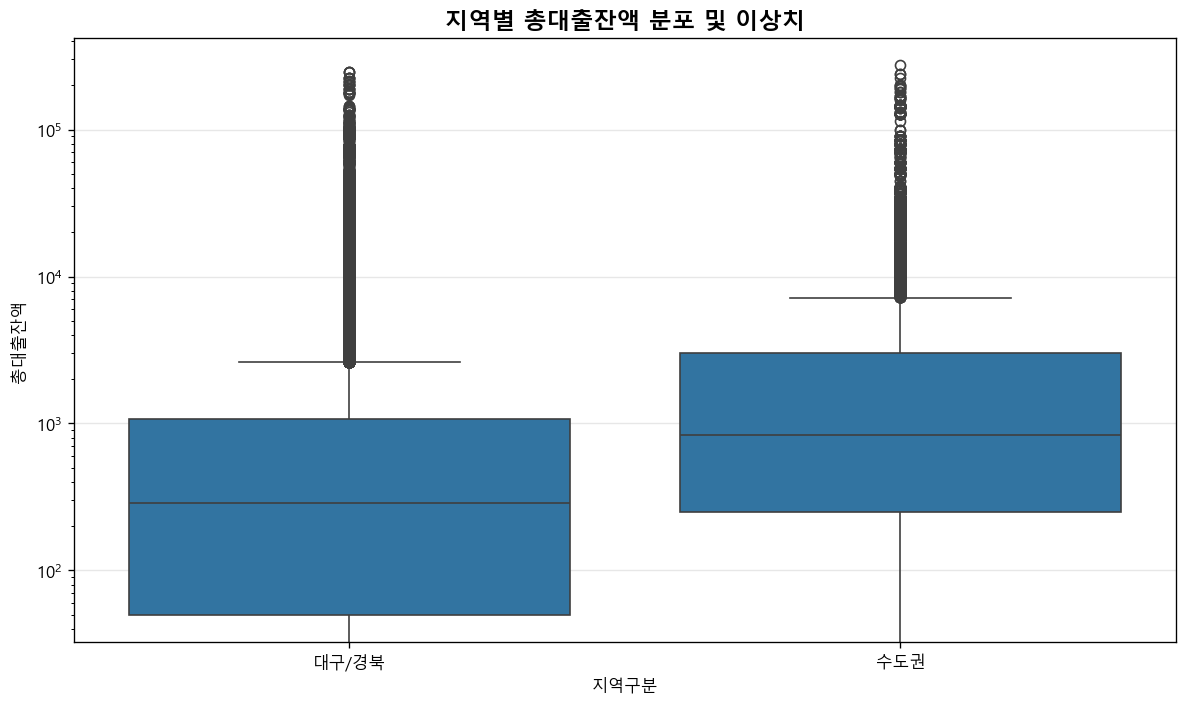

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 총대출 생성
df['총대출잔액'] = df['여신_운전자금대출잔액'].fillna(0) + df['여신_시설자금대출잔액'].fillna(0)

# 비교용 지역만
plot_df = df[df['지역구분'].isin(['수도권','대구/경북'])].copy()

plt.figure(figsize=(10,6))
sns.boxplot(data=plot_df, x='지역구분', y='총대출잔액')

plt.title('지역별 총대출잔액 분포 및 이상치', fontsize=14, fontweight='bold')
plt.ylabel('총대출잔액')
plt.xlabel('지역구분')
plt.yscale('log')  # 이상치가 크면 로그 추천
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

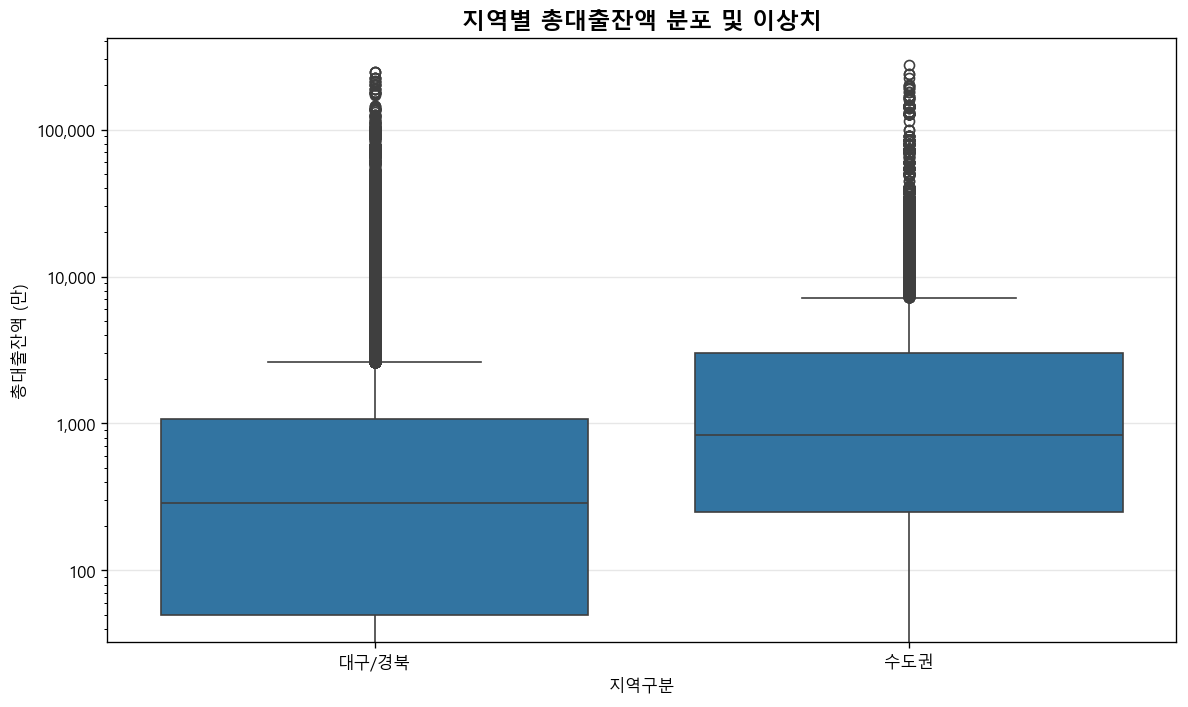

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 총대출 생성 (원본 단위)
df['총대출잔액'] = df['여신_운전자금대출잔액'].fillna(0) + df['여신_시설자금대출잔액'].fillna(0)

# 비교용 지역만
plot_df = df[df['지역구분'].isin(['수도권','대구/경북'])].copy()

plt.figure(figsize=(10,6))
sns.boxplot(data=plot_df, x='지역구분', y='총대출잔액')

plt.title('지역별 총대출잔액 분포 및 이상치', fontsize=14, fontweight='bold')
plt.ylabel('총대출잔액 (만)')
plt.xlabel('지역구분')
plt.yscale('log')  # 이상치가 크면 로그 추천
plt.grid(axis='y', alpha=0.3)

# y축 콤마 표시 (천 단위 콤마)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

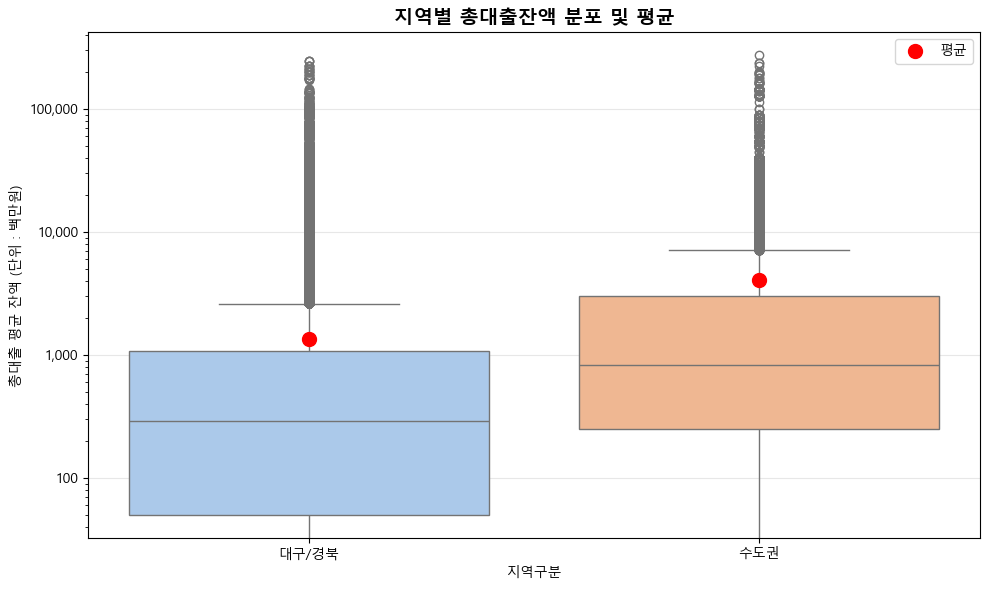

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 총대출 생성 (원본 단위)
df['총대출잔액'] = df['여신_운전자금대출잔액'].fillna(0) + df['여신_시설자금대출잔액'].fillna(0)

# 비교용 지역만
plot_df = df[df['지역구분'].isin(['수도권','대구/경북'])].copy()

plt.figure(figsize=(10,6))

# 박스플롯
sns.boxplot(data=plot_df, x='지역구분', y='총대출잔액', palette='pastel')

# 지역별 평균값 계산
mean_values = plot_df.groupby('지역구분')['총대출잔액'].mean()

# 평균값 점으로 표시
for i, region in enumerate(mean_values.index):
    plt.scatter(i, mean_values[region], color='red', s=100, zorder=5, label='평균' if i==0 else "")

plt.title('지역별 총대출잔액 분포 및 평균', fontsize=14, fontweight='bold')
plt.ylabel('총대출 평균 잔액 (단위 : 백만원)')
plt.xlabel('지역구분')
plt.yscale('log')  # 이상치가 크면 로그 스케일 추천
plt.grid(axis='y', alpha=0.3)

# y축 콤마 표시
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.legend()
plt.tight_layout()
plt.show()

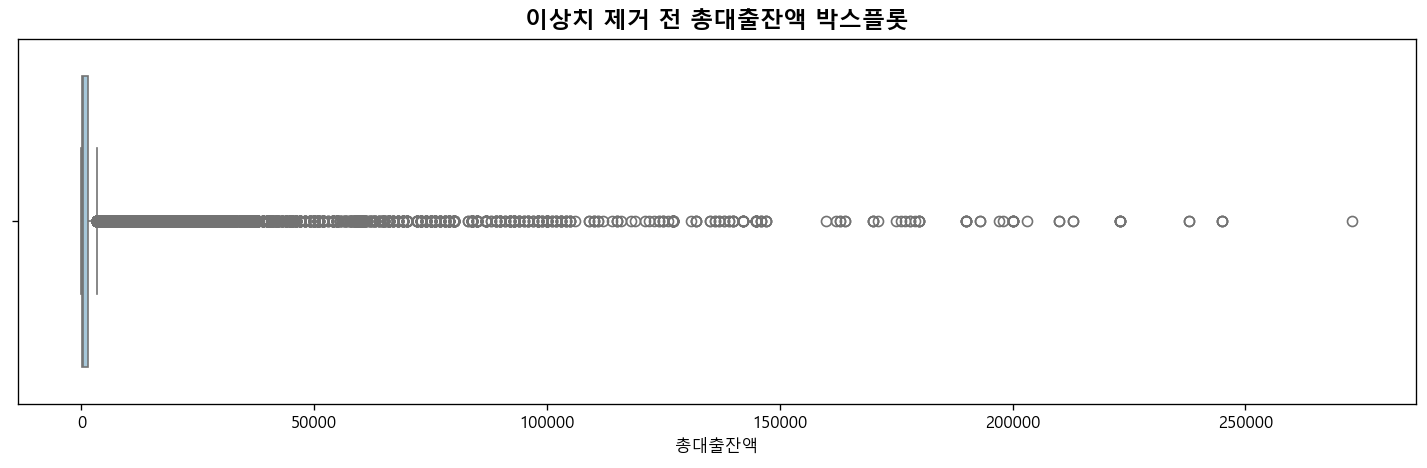

===== IQR 기준 계산 =====
Q1 (1사분위수): 100.00
Q3 (3사분위수): 1,400.00
IQR: 1,300.00
하한값: -1,850.00
상한값: 3,350.00

===== 이상치 개수 =====
정상치 개수: 282,319개
이상치 개수: 37,373개
전체 개수: 319,692개
이상치 비율: 11.69%

===== 제거 전/후 비교 =====
제거 전: 319,692개
제거 후: 282,319개
제거된 행 수: 37,373개


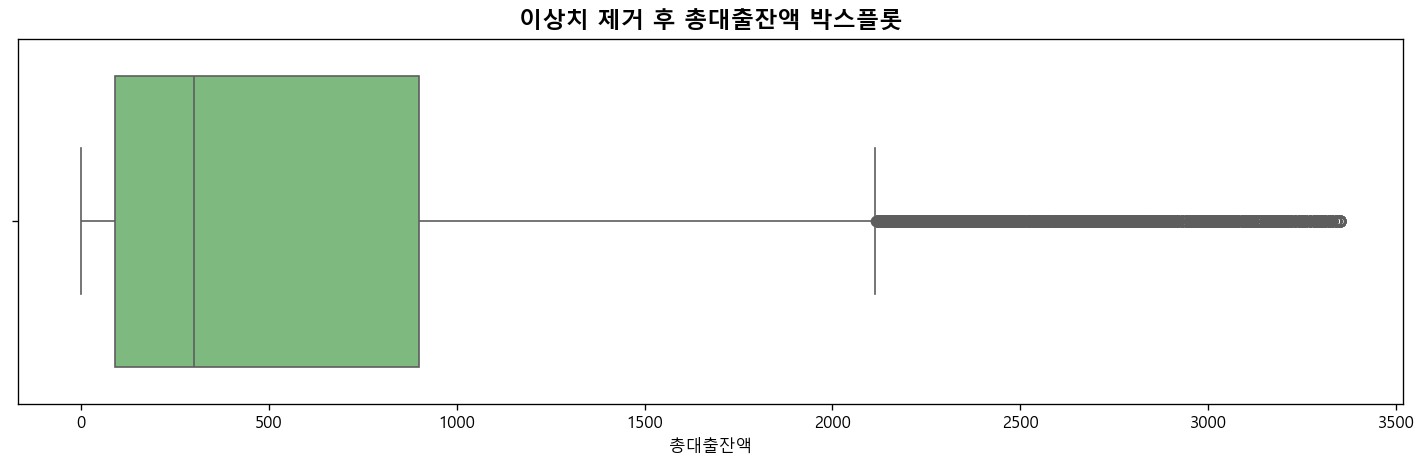

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 0. 총대출잔액 생성
# ==========================================
df['총대출잔액'] = (
    df['여신_운전자금대출잔액'].fillna(0) +
    df['여신_시설자금대출잔액'].fillna(0)
)

# ==========================================
# 1. 분석 대상 컬럼 선택
# ==========================================
target = '총대출잔액'

# 0 이하 제거 (필요 시)
df_iqr = df[df[target] > 0].copy()

# ==========================================
# 2. 이상치 제거 전 박스플롯
# ==========================================
plt.figure(figsize=(12, 4))
sns.boxplot(x=df_iqr[target], color='#9ecae1')
plt.title('이상치 제거 전 총대출잔액 박스플롯', fontsize=14, fontweight='bold')
plt.xlabel('총대출잔액')
plt.tight_layout()
plt.show()

# ==========================================
# 3. IQR 계산
# ==========================================
Q1 = df_iqr[target].quantile(0.25)
Q3 = df_iqr[target].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("===== IQR 기준 계산 =====")
print(f"Q1 (1사분위수): {Q1:,.2f}")
print(f"Q3 (3사분위수): {Q3:,.2f}")
print(f"IQR: {IQR:,.2f}")
print(f"하한값: {lower:,.2f}")
print(f"상한값: {upper:,.2f}")

# ==========================================
# 4. 이상치 여부 컬럼 생성
# ==========================================
df_iqr['이상치여부'] = np.where(
    (df_iqr[target] < lower) | (df_iqr[target] > upper),
    '이상치',
    '정상치'
)

# 이상치 개수 확인
outlier_count = (df_iqr['이상치여부'] == '이상치').sum()
normal_count = (df_iqr['이상치여부'] == '정상치').sum()

print("\n===== 이상치 개수 =====")
print(f"정상치 개수: {normal_count:,}개")
print(f"이상치 개수: {outlier_count:,}개")
print(f"전체 개수: {len(df_iqr):,}개")
print(f"이상치 비율: {outlier_count / len(df_iqr) * 100:.2f}%")

# ==========================================
# 5. 실제 이상치 제거
# ==========================================
df_clean = df_iqr[
    (df_iqr[target] >= lower) &
    (df_iqr[target] <= upper)
].copy()

print("\n===== 제거 전/후 비교 =====")
print(f"제거 전: {len(df_iqr):,}개")
print(f"제거 후: {len(df_clean):,}개")
print(f"제거된 행 수: {len(df_iqr) - len(df_clean):,}개")

# ==========================================
# 6. 이상치 제거 후 박스플롯
# ==========================================
plt.figure(figsize=(12, 4))
sns.boxplot(x=df_clean[target], color='#74c476')
plt.title('이상치 제거 후 총대출잔액 박스플롯', fontsize=14, fontweight='bold')
plt.xlabel('총대출잔액')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

# ==========================================
# 1. 수도권 필터링
# ==========================================
metro = df[df['지역구분'] == '수도권'].copy()

# 날짜형 확인
metro['기준년월_dt'] = pd.to_datetime(metro['기준년월'].astype(str), format='%Y%m')

# 결측 처리
metro['여신_운전자금대출잔액'] = metro['여신_운전자금대출잔액'].fillna(0)
metro['여신_시설자금대출잔액'] = metro['여신_시설자금대출잔액'].fillna(0)

# ==========================================
# 2. 월별 집계 (법인당 평균 계산용)
# ==========================================
monthly_funds = metro.groupby('기준년월_dt').agg(
    운전자금총액=('여신_운전자금대출잔액', 'sum'),
    시설자금총액=('여신_시설자금대출잔액', 'sum'),
    법인수=('여신_운전자금대출잔액', 'count')
).reset_index()

monthly_funds['법인당_운전자금'] = monthly_funds['운전자금총액'] / monthly_funds['법인수']
monthly_funds['법인당_시설자금'] = monthly_funds['시설자금총액'] / monthly_funds['법인수']

# ==========================================
# 3. 금리 구간 분리
# ==========================================
low_period = monthly_funds[
    (monthly_funds['기준년월_dt'] >= '2022-01-01') &
    (monthly_funds['기준년월_dt'] <= '2022-03-31')
].copy()

high_period = monthly_funds[
    (monthly_funds['기준년월_dt'] >= '2023-01-01') &
    (monthly_funds['기준년월_dt'] <= '2024-01-31')
].copy()

# ==========================================
# 4. 평균 계산
# ==========================================
low_work_mean = low_period['법인당_운전자금'].mean()
high_work_mean = high_period['법인당_운전자금'].mean()

low_fac_mean = low_period['법인당_시설자금'].mean()
high_fac_mean = high_period['법인당_시설자금'].mean()

work_change_pct = (high_work_mean - low_work_mean) / low_work_mean * 100
fac_change_pct = (high_fac_mean - low_fac_mean) / low_fac_mean * 100

# ==========================================
# 5. 변화량 벡터 생성
#    (월별 평균 수준 차이 비교용)
# ==========================================
# 각 월 관측치 자체를 비교하기 위해 구간별 월 데이터 사용
# 길이가 다르므로 "평균 수준 비교"는 independent t-test,
# "변화량 자체 비교"는 요약값으로만 봐야 함
# 발표에서는 아래처럼 각 자금별 전후 변화 유의성 + 변화율 비교로 충분

t_work, p_work = stats.ttest_ind(
    high_period['법인당_운전자금'],
    low_period['법인당_운전자금'],
    equal_var=False
)

t_fac, p_fac = stats.ttest_ind(
    high_period['법인당_시설자금'],
    low_period['법인당_시설자금'],
    equal_var=False
)

# ==========================================
# 6. 출력
# ==========================================
print("\n===== 수도권 운전자금 vs 시설자금 금리 민감도 분석 =====")

print("\n[운전자금 대출]")
print(f"저금리 평균: {low_work_mean:,.0f}")
print(f"고금리 평균: {high_work_mean:,.0f}")
print(f"변화율: {work_change_pct:+.2f}%")
print(f"t값: {t_work:.4f}")
print(f"p값: {p_work:.4f}")

print("\n[시설자금 대출]")
print(f"저금리 평균: {low_fac_mean:,.0f}")
print(f"고금리 평균: {high_fac_mean:,.0f}")
print(f"변화율: {fac_change_pct:+.2f}%")
print(f"t값: {t_fac:.4f}")
print(f"p값: {p_fac:.4f}")


===== 수도권 운전자금 vs 시설자금 금리 민감도 분석 =====

[운전자금 대출]
저금리 평균: 1,865
고금리 평균: 2,211
변화율: +18.52%
t값: 7.2645
p값: 0.0000

[시설자금 대출]
저금리 평균: 1,795
고금리 평균: 1,806
변화율: +0.64%
t값: 0.2352
p값: 0.8175


In [ ]:
# ==========================================
# 1. 저금리 / 고금리 평균 차이 계산
# ==========================================
work_diff = high_work_mean - low_work_mean
fac_diff = high_fac_mean - low_fac_mean

print("\n===== 변화량 비교 =====")
print(f"운전자금 증가금액: {work_diff:,.0f}")
print(f"시설자금 증가금액: {fac_diff:,.0f}")


===== 변화량 비교 =====
운전자금 증가금액: 345
시설자금 증가금액: 11


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

# ==========================================
# 0. 한글 폰트 (윈도우 기준)
# ==========================================
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 전처리
# ==========================================
df = df.copy()

# 날짜 변환
df['기준년월_dt'] = pd.to_datetime(df['기준년월'].astype(str), format='%Y%m')

# 수도권 필터
metro = df[df['지역구분'] == '수도권'].copy()

# 결측치 처리
metro['여신_운전자금대출잔액'] = metro['여신_운전자금대출잔액'].fillna(0)
metro['여신_시설자금대출잔액'] = metro['여신_시설자금대출잔액'].fillna(0)

# 총대출 생성
metro['총대출잔액'] = metro['여신_운전자금대출잔액'] + metro['여신_시설자금대출잔액']

# ==========================================
# 2. 월별 법인당 평균 집계
# ==========================================
monthly = metro.groupby('기준년월_dt').agg(
    총대출=('총대출잔액', 'sum'),
    운전자금=('여신_운전자금대출잔액', 'sum'),
    시설자금=('여신_시설자금대출잔액', 'sum'),
    법인수=('총대출잔액', 'count')
).reset_index()

monthly['총대출_법인당'] = monthly['총대출'] / monthly['법인수']
monthly['운전자금_법인당'] = monthly['운전자금'] / monthly['법인수']
monthly['시설자금_법인당'] = monthly['시설자금'] / monthly['법인수']

# ==========================================
# 3. 금리 전/후 구간 분리
# ==========================================
low = monthly[
    (monthly['기준년월_dt'] >= '2022-01-01') &
    (monthly['기준년월_dt'] <= '2022-03-31')
]

high = monthly[
    (monthly['기준년월_dt'] >= '2023-01-01') &
    (monthly['기준년월_dt'] <= '2024-01-31')
]

# ==========================================
# 4. t-test 함수
# ==========================================
def run_ttest(low_series, high_series, title=''):
    low_mean = low_series.mean()
    high_mean = high_series.mean()
    change_pct = ((high_mean - low_mean) / low_mean) * 100
    change_amt = high_mean - low_mean

    t_stat, p_val = stats.ttest_ind(high_series, low_series, equal_var=False)

    print(f"\n===== {title} =====")
    print(f"저금리 평균: {low_mean:,.0f}")
    print(f"고금리 평균: {high_mean:,.0f}")
    print(f"변화율: {change_pct:+.2f}%")
    print(f"증가금액: {change_amt:,.0f}")
    print(f"t값: {t_stat:.4f}")
    print(f"p값: {p_val:.4f}")

    return {
        '저금리평균': low_mean,
        '고금리평균': high_mean,
        '증가금액': change_amt,
        '변화율': change_pct,
        't값': t_stat,
        'p값': p_val
    }

# ==========================================
# 5. 분석 실행
# ==========================================
result_total = run_ttest(low['총대출_법인당'], high['총대출_법인당'], '수도권 총대출')
result_work = run_ttest(low['운전자금_법인당'], high['운전자금_법인당'], '수도권 운전자금 대출')
result_fac = run_ttest(low['시설자금_법인당'], high['시설자금_법인당'], '수도권 시설자금 대출')


===== 수도권 총대출 =====
저금리 평균: 3,660
고금리 평균: 4,017
변화율: +9.75%
증가금액: 357
t값: 3.9807
p값: 0.0016

===== 수도권 운전자금 대출 =====
저금리 평균: 1,865
고금리 평균: 2,211
변화율: +18.52%
증가금액: 345
t값: 7.2645
p값: 0.0000

===== 수도권 시설자금 대출 =====
저금리 평균: 1,795
고금리 평균: 1,806
변화율: +0.64%
증가금액: 11
t값: 0.2352
p값: 0.8175


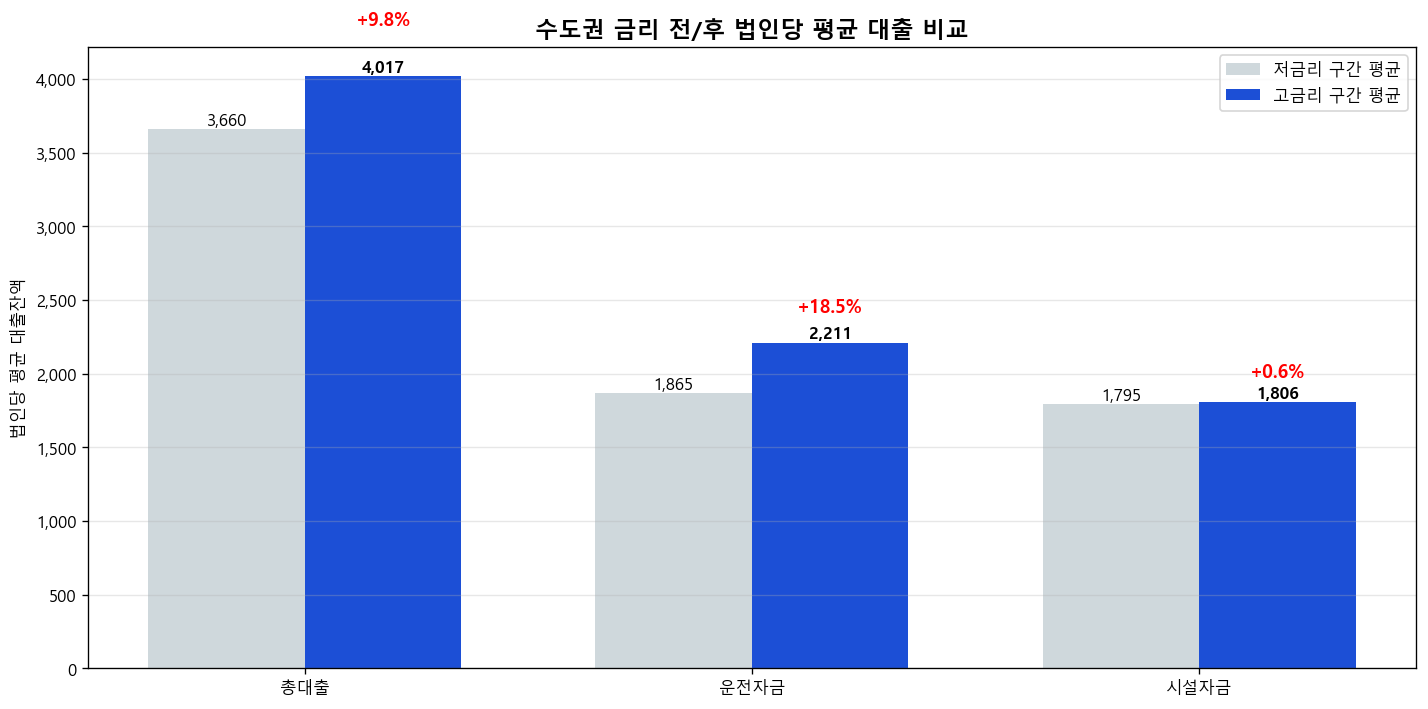

In [ ]:
# ==========================================
# 6. 운전자금 vs 시설자금 비교 막대그래프
# ==========================================
compare_df = pd.DataFrame({
    '구분': ['총대출', '운전자금', '시설자금'],
    '저금리': [result_total['저금리평균'], result_work['저금리평균'], result_fac['저금리평균']],
    '고금리': [result_total['고금리평균'], result_work['고금리평균'], result_fac['고금리평균']],
    '변화율': [result_total['변화율'], result_work['변화율'], result_fac['변화율']]
})

x = np.arange(len(compare_df))
width = 0.35

plt.figure(figsize=(12,6))
bars1 = plt.bar(x - width/2, compare_df['저금리'], width, label='저금리 구간 평균', color='#cfd8dc')
bars2 = plt.bar(x + width/2, compare_df['고금리'], width, label='고금리 구간 평균', color='#1c4fd6')

# 값 표시
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=10)

for i, bar in enumerate(bars2):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    # 변화율 표시
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.08,
             f"{compare_df['변화율'].iloc[i]:+.1f}%",
             ha='center', va='bottom', fontsize=11, fontweight='bold', color='red')

plt.title('수도권 금리 전/후 법인당 평균 대출 비교', fontsize=14, fontweight='bold')
plt.xticks(x, compare_df['구분'])
plt.ylabel('법인당 평균 대출잔액')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

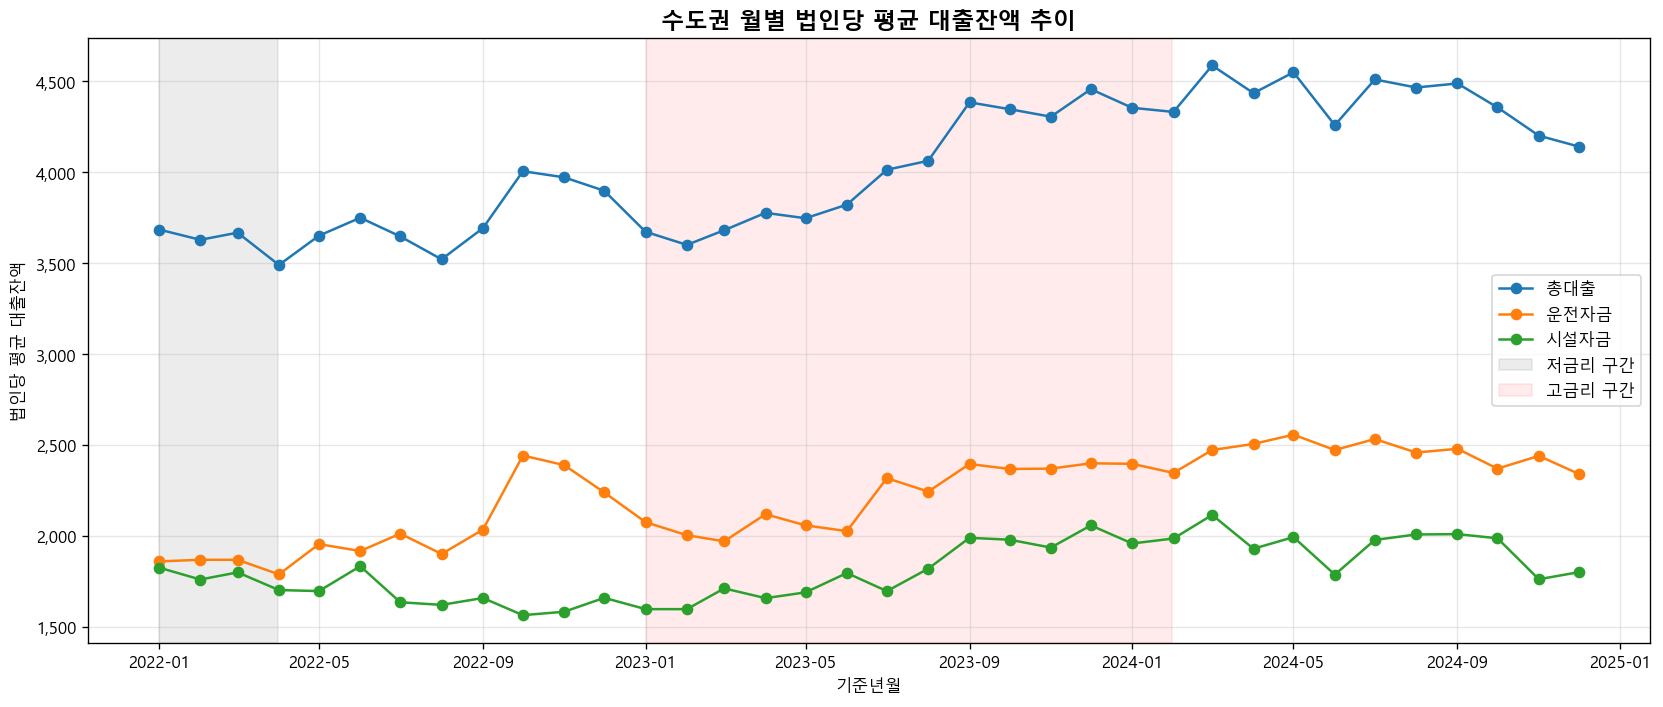

In [ ]:
# ==========================================
# 7. 월별 시계열 비교
# ==========================================
plt.figure(figsize=(14,6))

plt.plot(monthly['기준년월_dt'], monthly['총대출_법인당'], marker='o', label='총대출')
plt.plot(monthly['기준년월_dt'], monthly['운전자금_법인당'], marker='o', label='운전자금')
plt.plot(monthly['기준년월_dt'], monthly['시설자금_법인당'], marker='o', label='시설자금')

# 금리 인상 시점 시각적 표시 (예시)
plt.axvspan(pd.to_datetime('2022-01-01'), pd.to_datetime('2022-03-31'),
            color='gray', alpha=0.15, label='저금리 구간')
plt.axvspan(pd.to_datetime('2023-01-01'), pd.to_datetime('2024-01-31'),
            color='red', alpha=0.08, label='고금리 구간')

plt.title('수도권 월별 법인당 평균 대출잔액 추이', fontsize=14, fontweight='bold')
plt.xlabel('기준년월')
plt.ylabel('법인당 평균 대출잔액')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# ==========================================
# 0. 데이터 복사
# ==========================================
test_df = df.copy()

# ==========================================
# 1. 사용 칼럼 확인용 출력
# ==========================================
print("\n" + "="*60)
print(" [운전자금 vs 시설자금 금리 민감도 분석] 사용 칼럼")
print("="*60)

used_columns = [
    '기준년월',
    '사업장_시도',
    '지역구분',
    '여신_운전자금대출잔액',
    '여신_시설자금대출잔액'
]

print("\n[원본 사용 칼럼]")
for col in used_columns:
    print(f"- {col}")

print("\n[파생 변수 생성 방식]")
print("1) 총대출잔액 = 여신_운전자금대출잔액 + 여신_시설자금대출잔액")
print("2) 기준년월_dt = 기준년월을 datetime으로 변환")
print("3) 월별 법인당 평균 = 월별 총합 / 월별 법인 수")
print("4) 분석 대상 = 수도권 지역구분만 필터링")
print("5) 비교 구간:")
print("   - 저금리 구간: 2022-01 ~ 2022-03")
print("   - 고금리 구간: 2023-01 ~ 2024-01")

# ==========================================
# 2. 전처리
# ==========================================
test_df['기준년월_dt'] = pd.to_datetime(test_df['기준년월'].astype(str), format='%Y%m')

test_df['여신_운전자금대출잔액'] = test_df['여신_운전자금대출잔액'].fillna(0)
test_df['여신_시설자금대출잔액'] = test_df['여신_시설자금대출잔액'].fillna(0)

test_df['총대출잔액'] = (
    test_df['여신_운전자금대출잔액'] +
    test_df['여신_시설자금대출잔액']
)

# 수도권만 필터링
metro = test_df[test_df['지역구분'] == '수도권'].copy()

# ==========================================
# 3. 월별 집계
# ==========================================
monthly = metro.groupby('기준년월_dt').agg(
    총대출=('총대출잔액', 'sum'),
    운전자금=('여신_운전자금대출잔액', 'sum'),
    시설자금=('여신_시설자금대출잔액', 'sum'),
    법인수=('총대출잔액', 'count')
).reset_index()

monthly['총대출_법인당'] = monthly['총대출'] / monthly['법인수']
monthly['운전자금_법인당'] = monthly['운전자금'] / monthly['법인수']
monthly['시설자금_법인당'] = monthly['시설자금'] / monthly['법인수']

# ==========================================
# 4. 금리 구간 분리
# ==========================================
low = monthly[
    (monthly['기준년월_dt'] >= '2022-01-01') &
    (monthly['기준년월_dt'] <= '2022-03-31')
].copy()

high = monthly[
    (monthly['기준년월_dt'] >= '2023-01-01') &
    (monthly['기준년월_dt'] <= '2024-01-31')
].copy()

# ==========================================
# 5. t-test 함수
# ==========================================
def run_ttest(low_series, high_series, title=''):
    low_mean = low_series.mean()
    high_mean = high_series.mean()
    change_pct = ((high_mean - low_mean) / low_mean) * 100
    change_amt = high_mean - low_mean

    t_stat, p_val = stats.ttest_ind(high_series, low_series, equal_var=False)

    print("\n" + "="*60)
    print(f" [{title}]")
    print("="*60)
    print(f"저금리 평균: {low_mean:,.0f}")
    print(f"고금리 평균: {high_mean:,.0f}")
    print(f"증가금액: {change_amt:,.0f}")
    print(f"변화율: {change_pct:+.2f}%")
    print(f"t값: {t_stat:.4f}")
    print(f"p값: {p_val:.4f}")

    if p_val < 0.05:
        print("→ 해석: 통계적으로 유의한 차이가 있음 (귀무가설 기각)")
    else:
        print("→ 해석: 통계적으로 유의한 차이가 없음 (귀무가설 채택)")

    return {
        '저금리평균': low_mean,
        '고금리평균': high_mean,
        '증가금액': change_amt,
        '변화율': change_pct,
        't값': t_stat,
        'p값': p_val
    }

# ==========================================
# 6. 검정 실행
# ==========================================
print("\n" + "="*60)
print(" [t-test 검정 과정]")
print("="*60)
print("\n검정 방식: 독립표본 t-test (Welch's t-test)")
print("비교 단위: 월별 법인당 평균 대출잔액")
print("비교 집단:")
print(f"- 저금리 구간 표본 수: {len(low)}개월")
print(f"- 고금리 구간 표본 수: {len(high)}개월")

result_total = run_ttest(low['총대출_법인당'], high['총대출_법인당'], '총대출')
result_work = run_ttest(low['운전자금_법인당'], high['운전자금_법인당'], '운전자금 대출')
result_fac = run_ttest(low['시설자금_법인당'], high['시설자금_법인당'], '시설자금 대출')


 [운전자금 vs 시설자금 금리 민감도 분석] 사용 칼럼

[원본 사용 칼럼]
- 기준년월
- 사업장_시도
- 지역구분
- 여신_운전자금대출잔액
- 여신_시설자금대출잔액

[파생 변수 생성 방식]
1) 총대출잔액 = 여신_운전자금대출잔액 + 여신_시설자금대출잔액
2) 기준년월_dt = 기준년월을 datetime으로 변환
3) 월별 법인당 평균 = 월별 총합 / 월별 법인 수
4) 분석 대상 = 수도권 지역구분만 필터링
5) 비교 구간:
   - 저금리 구간: 2022-01 ~ 2022-03
   - 고금리 구간: 2023-01 ~ 2024-01

 [t-test 검정 과정]

검정 방식: 독립표본 t-test (Welch's t-test)
비교 단위: 월별 법인당 평균 대출잔액
비교 집단:
- 저금리 구간 표본 수: 3개월
- 고금리 구간 표본 수: 13개월

 [총대출]
저금리 평균: 3,660
고금리 평균: 4,017
증가금액: 357
변화율: +9.75%
t값: 3.9807
p값: 0.0016
→ 해석: 통계적으로 유의한 차이가 있음 (귀무가설 기각)

 [운전자금 대출]
저금리 평균: 1,865
고금리 평균: 2,211
증가금액: 345
변화율: +18.52%
t값: 7.2645
p값: 0.0000
→ 해석: 통계적으로 유의한 차이가 있음 (귀무가설 기각)

 [시설자금 대출]
저금리 평균: 1,795
고금리 평균: 1,806
증가금액: 11
변화율: +0.64%
t값: 0.2352
p값: 0.8175
→ 해석: 통계적으로 유의한 차이가 없음 (귀무가설 채택)


In [ ]:
# ============================================================
#  [운전자금 vs 시설자금 금리 민감도 분석] 사용 칼럼
# ============================================================

# [원본 사용 칼럼]
# - 기준년월
# - 사업장_시도
# - 지역구분
# - 여신_운전자금대출잔액
# - 여신_시설자금대출잔액

# [파생 변수 생성 방식]
# 1) 총대출잔액 = 여신_운전자금대출잔액 + 여신_시설자금대출잔액
# 2) 기준년월_dt = 기준년월을 datetime으로 변환
# 3) 월별 법인당 평균 = 월별 총합 / 월별 법인 수
# 4) 분석 대상 = 수도권 지역구분만 필터링
# 5) 비교 구간:
#    - 저금리 구간: 2022-01 ~ 2022-03
#    - 고금리 구간: 2023-01 ~ 2024-01

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mticker

# ==========================================
# [전제]
# monthly, low, high가 이미 만들어져 있다고 가정
# monthly['총대출_법인당'] = 운전자금_법인당 + 시설자금_법인당
# ==========================================

# 총대출 평균
low_total_mean = low['총대출_법인당'].mean()
high_total_mean = high['총대출_법인당'].mean()
total_change = ((high_total_mean - low_total_mean) / low_total_mean) * 100
total_diff = high_total_mean - low_total_mean

# ==========================================
# 시각화
# ==========================================
labels = ['저금리', '고금리']
values = [low_total_mean, high_total_mean]
colors = ['#cfd8dc', '#1c4fd6']

plt.figure(figsize=(8,6))
bars = plt.bar(labels, values, color=colors, width=0.55)

# 값 표시
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h,
             f'{h:,.0f}',
             ha='center', va='bottom',
             fontsize=11, fontweight='bold')

# 변화율 표시
plt.text(0.5, max(values) * 1.12,
         f'▲ {total_change:.2f}%\n(+{total_diff:,.0f})',
         ha='center', va='bottom',
         fontsize=13, fontweight='bold', color='#d63c1c',
         bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='#d63c1c', lw=1.5))

plt.title('수도권 평균 총대출 변화 (법인당)', fontsize=15, fontweight='bold')
plt.ylabel('법인당 평균 총대출잔액 (단위 : 백 만원)')

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, _: f'{y:,.0f}')
)

plt.ylim(0, max(values) * 1.25)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'low' is not defined

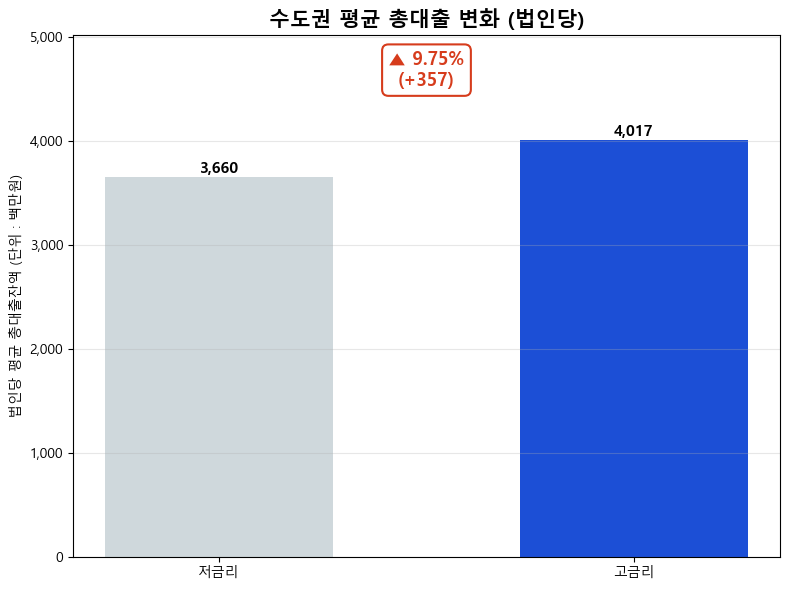

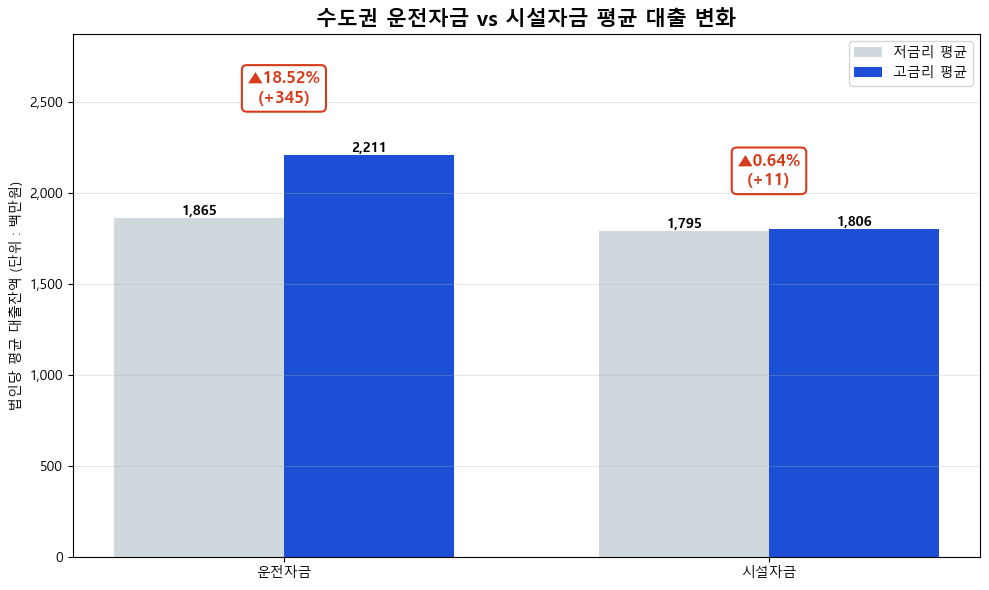

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ==========================================
# 1. 수도권 필터링
# ==========================================
metro = df[df['지역구분'] == '수도권'].copy()

# 기준년월 datetime 변환
metro['기준년월_dt'] = pd.to_datetime(metro['기준년월'].astype(str), format='%Y%m')

# 총대출 생성
metro['총대출잔액'] = (
    metro['여신_운전자금대출잔액'].fillna(0) +
    metro['여신_시설자금대출잔액'].fillna(0)
)

# ==========================================
# 2. 월별 집계
# ==========================================
monthly = metro.groupby('기준년월_dt').agg(
    운전자금총액=('여신_운전자금대출잔액', 'sum'),
    시설자금총액=('여신_시설자금대출잔액', 'sum'),
    총대출총액=('총대출잔액', 'sum'),
    법인수=('총대출잔액', 'count')
).reset_index()

# 법인당 평균
monthly['운전자금_법인당'] = monthly['운전자금총액'] / monthly['법인수']
monthly['시설자금_법인당'] = monthly['시설자금총액'] / monthly['법인수']
monthly['총대출_법인당'] = monthly['총대출총액'] / monthly['법인수']

# ==========================================
# 3. 저금리 / 고금리 구간 분리
# ==========================================
low = monthly[
    (monthly['기준년월_dt'] >= '2022-01-01') &
    (monthly['기준년월_dt'] <= '2022-03-31')
]

high = monthly[
    (monthly['기준년월_dt'] >= '2023-01-01') &
    (monthly['기준년월_dt'] <= '2024-01-31')
]

# ==========================================
# 4. 차트 1 - 총대출 변화
# ==========================================
low_total_mean = low['총대출_법인당'].mean()
high_total_mean = high['총대출_법인당'].mean()
total_change = ((high_total_mean - low_total_mean) / low_total_mean) * 100
total_diff = high_total_mean - low_total_mean

labels = ['저금리', '고금리']
values = [low_total_mean, high_total_mean]
colors = ['#cfd8dc', '#1c4fd6']

plt.figure(figsize=(8,6))
bars = plt.bar(labels, values, color=colors, width=0.55)

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h,
             f'{h:,.0f}',
             ha='center', va='bottom',
             fontsize=11, fontweight='bold')

plt.text(0.5, max(values) * 1.12,
         f'▲ {total_change:.2f}%\n(+{total_diff:,.0f})',
         ha='center', va='bottom',
         fontsize=13, fontweight='bold', color='#d63c1c',
         bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='#d63c1c', lw=1.5))

plt.title('수도권 평균 총대출 변화 (법인당)', fontsize=15, fontweight='bold')
plt.ylabel('법인당 평균 총대출잔액 (단위 : 백만원)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:,.0f}'))
plt.ylim(0, max(values) * 1.25)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# 5. 차트 2 - 운전자금 vs 시설자금
# ==========================================
categories = ['운전자금', '시설자금']
low_vals = [low['운전자금_법인당'].mean(), low['시설자금_법인당'].mean()]
high_vals = [high['운전자금_법인당'].mean(), high['시설자금_법인당'].mean()]
change_rates = [((high_vals[i] - low_vals[i]) / low_vals[i]) * 100 for i in range(2)]
change_amounts = [high_vals[i] - low_vals[i] for i in range(2)]

x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, low_vals, width, label='저금리 평균', color='#cfd8dc')
bars = plt.bar(x + width/2, high_vals, width, label='고금리 평균', color='#1c4fd6')

for i in range(len(categories)):
    plt.text(x[i] - width/2, low_vals[i], f'{low_vals[i]:,.0f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.text(x[i] + width/2, high_vals[i], f'{high_vals[i]:,.0f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

for i, rate in enumerate(change_rates):
    mark = '▲' if rate >= 0 else '▼'
    color = '#d63c1c' if rate >= 0 else '#1c4fd6'
    plt.text(x[i], max(low_vals[i], high_vals[i]) * 1.12,
             f'{mark}{abs(rate):.2f}%\n(+{change_amounts[i]:,.0f})',
             ha='center', va='bottom',
             fontsize=12, fontweight='bold', color=color,
             bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=color, lw=1.5))

plt.title('수도권 운전자금 vs 시설자금 평균 대출 변화', fontsize=15, fontweight='bold')
plt.ylabel('법인당 평균 대출잔액 (단위 : 백만원)')
plt.xticks(x, categories)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:,.0f}'))
plt.ylim(0, max(high_vals) * 1.3)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("===== 운전자금 vs 시설자금 금리 민감도 분석: 사용 컬럼 =====")

print("\n[원본 컬럼]")
print("1. 기준년월")
print("2. 지역구분")
print("3. 여신_운전자금대출잔액")
print("4. 여신_시설자금대출잔액")

print("\n[분석 대상]")
print("- 지역: 수도권")
print("- 기간 구분:")
print("  · 저금리 구간: 2022-01 ~ 2022-03")
print("  · 고금리 구간: 2023-01 ~ 2024-01")

print("\n[생성 변수]")
print("1. 월별 운전자금 법인당 평균 = 월별 운전자금 총합 / 월별 법인 수")
print("2. 월별 시설자금 법인당 평균 = 월별 시설자금 총합 / 월별 법인 수")

print("\n[검정 방법]")
print("- 독립표본 t-test (scipy.stats.ttest_ind)")
print("- 비교 단위: 월별 법인당 평균 대출잔액")

===== 운전자금 vs 시설자금 금리 민감도 분석: 사용 컬럼 =====

[원본 컬럼]
1. 기준년월
2. 지역구분
3. 여신_운전자금대출잔액
4. 여신_시설자금대출잔액

[분석 대상]
- 지역: 수도권
- 기간 구분:
  · 저금리 구간: 2022-01 ~ 2022-03
  · 고금리 구간: 2023-01 ~ 2024-01

[생성 변수]
1. 월별 운전자금 법인당 평균 = 월별 운전자금 총합 / 월별 법인 수
2. 월별 시설자금 법인당 평균 = 월별 시설자금 총합 / 월별 법인 수

[검정 방법]
- 독립표본 t-test (scipy.stats.ttest_ind)
- 비교 단위: 월별 법인당 평균 대출잔액


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# ==========================================
# 1. 수도권 필터링
# ==========================================
metro = df[df['지역구분'] == '수도권'].copy()

# 기준년월 datetime 변환 (없으면 생성)
metro['기준년월_dt'] = pd.to_datetime(metro['기준년월'].astype(str), format='%Y%m')

# ==========================================
# 2. 월별 집계
#    - 운전자금 총합
#    - 시설자금 총합
#    - 법인수
# ==========================================
monthly = metro.groupby('기준년월_dt').agg(
    운전자금총액=('여신_운전자금대출잔액', 'sum'),
    시설자금총액=('여신_시설자금대출잔액', 'sum'),
    법인수=('여신_운전자금대출잔액', 'count')
).reset_index()

# ==========================================
# 3. 법인당 평균 생성
# ==========================================
monthly['운전자금_법인당'] = monthly['운전자금총액'] / monthly['법인수']
monthly['시설자금_법인당'] = monthly['시설자금총액'] / monthly['법인수']

# 총대출도 참고용으로 추가
monthly['총대출_법인당'] = (
    monthly['운전자금_법인당'] + monthly['시설자금_법인당']
)

# ==========================================
# 4. 금리 구간 분리
# ==========================================
low = monthly[
    (monthly['기준년월_dt'] >= '2022-01-01') &
    (monthly['기준년월_dt'] <= '2022-03-31')
]

high = monthly[
    (monthly['기준년월_dt'] >= '2023-01-01') &
    (monthly['기준년월_dt'] <= '2024-01-31')
]

# ==========================================
# 5. 운전자금 t-test
# ==========================================
t_work, p_work = stats.ttest_ind(
    high['운전자금_법인당'],
    low['운전자금_법인당'],
    equal_var=False
)

low_work_mean = low['운전자금_법인당'].mean()
high_work_mean = high['운전자금_법인당'].mean()
work_change = ((high_work_mean - low_work_mean) / low_work_mean) * 100
work_diff = high_work_mean - low_work_mean

# ==========================================
# 6. 시설자금 t-test
# ==========================================
t_fac, p_fac = stats.ttest_ind(
    high['시설자금_법인당'],
    low['시설자금_법인당'],
    equal_var=False
)

low_fac_mean = low['시설자금_법인당'].mean()
high_fac_mean = high['시설자금_법인당'].mean()
fac_change = ((high_fac_mean - low_fac_mean) / low_fac_mean) * 100
fac_diff = high_fac_mean - low_fac_mean

# ==========================================
# 7. 출력
# ==========================================
print("===== 수도권 운전자금 vs 시설자금 금리 민감도 분석 =====")

print("\n[운전자금 대출]")
print(f"저금리 평균: {low_work_mean:,.0f}")
print(f"고금리 평균: {high_work_mean:,.0f}")
print(f"변화율: {work_change:+.2f}%")
print(f"증가금액: {work_diff:,.0f}")
print(f"t값: {t_work:.4f}")
print(f"p값: {p_work:.4f}")

print("\n[시설자금 대출]")
print(f"저금리 평균: {low_fac_mean:,.0f}")
print(f"고금리 평균: {high_fac_mean:,.0f}")
print(f"변화율: {fac_change:+.2f}%")
print(f"증가금액: {fac_diff:,.0f}")
print(f"t값: {t_fac:.4f}")
print(f"p값: {p_fac:.4f}")

print("\n===== 변화량 비교 =====")
print(f"운전자금 증가금액: {work_diff:,.0f}")
print(f"시설자금 증가금액: {fac_diff:,.0f}")

===== 수도권 운전자금 vs 시설자금 금리 민감도 분석 =====

[운전자금 대출]
저금리 평균: 1,865
고금리 평균: 2,211
변화율: +18.52%
증가금액: 345
t값: 7.2645
p값: 0.0000

[시설자금 대출]
저금리 평균: 1,795
고금리 평균: 1,806
변화율: +0.64%
증가금액: 11
t값: 0.2352
p값: 0.8175

===== 변화량 비교 =====
운전자금 증가금액: 345
시설자금 증가금액: 11


In [ ]:
# 금리 변화에 따른 대출잔액 변화 t-test 결과
# 운전자금
driver_t = 7.2645
driver_p = 0.0000

# 시설자금
facility_t = 0.2352
facility_p = 0.8175

# 유의수준
alpha = 0.05

# 결과 출력 함수
def interpret_ttest(t, p, alpha=0.05, loan_type="대출"):
    print(f"[{loan_type}] t값: {t:.4f}, p값: {p:.4f}")
    if p < alpha:
        print(f"→ p < {alpha}, 귀무가설 기각: 금리 변화에 따른 {loan_type} 변동이 통계적으로 유의미함.\n")
    else:
        print(f"→ p >= {alpha}, 귀무가설 채택: 금리 변화에 따른 {loan_type} 변동이 통계적으로 유의미하지 않음.\n")

# 결과 확인
interpret_ttest(driver_t, driver_p, alpha, "운전자금")
interpret_ttest(facility_t, facility_p, alpha, "시설자금")

# 민감도 비교 (퍼센트 기준)
driver_rate = 18.52  # 운전자금 변화율 %
facility_rate = 0.64  # 시설자금 변화율 %

print("===== 민감도 비교 (퍼센트 기준) =====")
print(f"운전자금 변화율: {driver_rate:.2f}%")
print(f"시설자금 변화율: {facility_rate:.2f}%")

if driver_rate > facility_rate:
    print("→ 운전자금이 시설자금보다 금리 변화에 더 민감함 (귀무가설 기각)")
else:
    print("→ 시설자금이 운전자금보다 금리 변화에 더 민감함 (대립가설 지지)")

[운전자금] t값: 7.2645, p값: 0.0000
→ p < 0.05, 귀무가설 기각: 금리 변화에 따른 운전자금 변동이 통계적으로 유의미함.

[시설자금] t값: 0.2352, p값: 0.8175
→ p >= 0.05, 귀무가설 채택: 금리 변화에 따른 시설자금 변동이 통계적으로 유의미하지 않음.

===== 민감도 비교 (퍼센트 기준) =====
운전자금 변화율: 18.52%
시설자금 변화율: 0.64%
→ 운전자금이 시설자금보다 금리 변화에 더 민감함 (귀무가설 기각)


In [ ]:
# ===== 수도권 운전자금 vs 시설자금 금리 민감도 분석 자동 보고 =====

# 운전자금 데이터
driver = {
    "low_rate_avg": 1865,
    "high_rate_avg": 2211,
    "increase_amount": 345,
    "change_percent": 18.52,
    "t_value": 7.2645,
    "p_value": 0.0000
}

# 시설자금 데이터
facility = {
    "low_rate_avg": 1795,
    "high_rate_avg": 1806,
    "increase_amount": 11,
    "change_percent": 0.64,
    "t_value": 0.2352,
    "p_value": 0.8175
}

alpha = 0.05  # 유의수준

# 결과 해석 함수
def interpret_ttest(t, p, loan_type):
    print(f"[{loan_type}] t값: {t:.4f}, p값: {p:.4f}")
    if p < alpha:
        print(f"→ p < {alpha}, 귀무가설 기각: 금리 변화에 따른 {loan_type} 변동이 통계적으로 유의미함.\n")
    else:
        print(f"→ p >= {alpha}, 귀무가설 채택: 금리 변화에 따른 {loan_type} 변동이 통계적으로 유의미하지 않음.\n")

# ===== 보고서 출력 =====
print("===== 수도권 운전자금 vs 시설자금 금리 t-test 분석 =====\n")

# 운전자금
print("### [운전자금 대출]")
print(f"저금리 평균: {driver['low_rate_avg']}")
print(f"고금리 평균: {driver['high_rate_avg']}")
print(f"증가금액: {driver['increase_amount']}")
print(f"변화율: {driver['change_percent']:.2f}%")
interpret_ttest(driver['t_value'], driver['p_value'], "운전자금")

# 시설자금
print("### [시설자금 대출]")
print(f"저금리 평균: {facility['low_rate_avg']}")
print(f"고금리 평균: {facility['high_rate_avg']}")
print(f"증가금액: {facility['increase_amount']}")
print(f"변화율: {facility['change_percent']:.2f}%")
interpret_ttest(facility['t_value'], facility['p_value'], "시설자금")

# 민감도 비교
print("### ===== 민감도 비교 (퍼센트 기준) =====")
print(f"운전자금 변화율: {driver['change_percent']:.2f}%")
print(f"시설자금 변화율: {facility['change_percent']:.2f}%")

if driver['change_percent'] > facility['change_percent']:
    print("→ 운전자금이 시설자금보다 금리 변화에 훨씬 더 민감함 (대립가설 지지, 귀무가설 기각)")
else:
    print("→ 시설자금이 운전자금보다 금리 변화에 더 민감함 (대립가설 지지, 귀무가설 기각)")

===== 수도권 운전자금 vs 시설자금 금리 t-test 분석 =====

### [운전자금 대출]
저금리 평균: 1865
고금리 평균: 2211
증가금액: 345
변화율: 18.52%
[운전자금] t값: 7.2645, p값: 0.0000
→ p < 0.05, 귀무가설 기각: 금리 변화에 따른 운전자금 변동이 통계적으로 유의미함.

### [시설자금 대출]
저금리 평균: 1795
고금리 평균: 1806
증가금액: 11
변화율: 0.64%
[시설자금] t값: 0.2352, p값: 0.8175
→ p >= 0.05, 귀무가설 채택: 금리 변화에 따른 시설자금 변동이 통계적으로 유의미하지 않음.

### ===== 민감도 비교 (퍼센트 기준) =====
운전자금 변화율: 18.52%
시설자금 변화율: 0.64%
→ 운전자금이 시설자금보다 금리 변화에 훨씬 더 민감함 (대립가설 지지, 귀무가설 기각)


In [ ]:
# ===== 지역별 금리 민감도 분석 자동 보고 =====

# 수도권 데이터
seoul_region = {
    "region_name": "수도권",
    "low_rate_avg": 3660,
    "high_rate_avg": 4017,
    "change_percent": 9.75,
    "t_value": 3.9807,
    "p_value": 0.0016
}

# 대구경북 데이터
daegu_region = {
    "region_name": "대구경북",
    "low_rate_avg": 1328,
    "high_rate_avg": 1343,
    "change_percent": 1.18,
    "t_value": 1.8570,
    "p_value": 0.1279
}

alpha = 0.05  # 유의수준

# t-test 결과 해석 함수
def interpret_ttest(t, p, region_name):
    print(f"[{region_name}] t값: {t:.4f}, p값: {p:.4f}")
    if p < alpha:
        print(f"→ p < {alpha}, 귀무가설 기각: 금리 변화에 따른 {region_name} 변동이 통계적으로 유의미함.\n")
    else:
        print(f"→ p >= {alpha}, 귀무가설 채택: 금리 변화에 따른 {region_name} 변동이 통계적으로 유의미하지 않음.\n")

# ===== 보고서 출력 =====
print("===== 지역별 금리 t-test 분석 =====\n")

# 수도권
print(f"### [{seoul_region['region_name']}]")
print(f"저금리 평균: {seoul_region['low_rate_avg']}")
print(f"고금리 평균: {seoul_region['high_rate_avg']}")
print(f"변화율: {seoul_region['change_percent']:.2f}%")
interpret_ttest(seoul_region['t_value'], seoul_region['p_value'], seoul_region['region_name'])

# 대구경북
print(f"### [{daegu_region['region_name']}]")
print(f"저금리 평균: {daegu_region['low_rate_avg']}")
print(f"고금리 평균: {daegu_region['high_rate_avg']}")
print(f"변화율: {daegu_region['change_percent']:.2f}%")
interpret_ttest(daegu_region['t_value'], daegu_region['p_value'], daegu_region['region_name'])

# 민감도 비교
print("### ===== 민감도 비교 (퍼센트 기준) =====")
print(f"{seoul_region['region_name']} 변화율: {seoul_region['change_percent']:.2f}%")
print(f"{daegu_region['region_name']} 변화율: {daegu_region['change_percent']:.2f}%")

if seoul_region['change_percent'] > daegu_region['change_percent']:
    print(f"→ {seoul_region['region_name']}이 {daegu_region['region_name']}보다 금리 변화에 훨씬 더 민감함 (대립가설 지지, 귀무가설 기각)")
else:
    print(f"→ {daegu_region['region_name']}이 {seoul_region['region_name']}보다 금리 변화에 더 민감함 (대립가설 지지, 귀무가설 기각)")

===== 지역별 금리 t-test 분석 =====

### [수도권]
저금리 평균: 3660
고금리 평균: 4017
변화율: 9.75%
[수도권] t값: 3.9807, p값: 0.0016
→ p < 0.05, 귀무가설 기각: 금리 변화에 따른 수도권 변동이 통계적으로 유의미함.

### [대구경북]
저금리 평균: 1328
고금리 평균: 1343
변화율: 1.18%
[대구경북] t값: 1.8570, p값: 0.1279
→ p >= 0.05, 귀무가설 채택: 금리 변화에 따른 대구경북 변동이 통계적으로 유의미하지 않음.

### ===== 민감도 비교 (퍼센트 기준) =====
수도권 변화율: 9.75%
대구경북 변화율: 1.18%
→ 수도권이 대구경북보다 금리 변화에 훨씬 더 민감함 (대립가설 지지, 귀무가설 기각)


In [ ]:
df['기준년월'].value_counts()

기준년월
202211    9994
202411    9980
202301    9970
202408    9904
202410    9902
202407    9842
202308    9815
202307    9799
202310    9791
202311    9784
202405    9778
202208    9769
202210    9746
202404    9733
202207    9712
202412    9712
202305    9697
202401    9686
202409    9672
202302    9641
202304    9623
202402    9601
202205    9586
202209    9584
202306    9543
202212    9498
202204    9489
202206    9484
202202    9461
202201    9432
202406    9428
202312    9428
202309    9404
202303    9350
202203    9255
202403    9206
Name: count, dtype: int64

In [ ]:
import pandas as pd

# df는 제공하신 데이터프레임
# 수도권 필터
seoul_df = df[df['지역구분'] == '수도권']

# 운전자금 / 시설자금 총액 합계
driver_total = seoul_df['여신_운전자금대출잔액'].sum()
facility_total = seoul_df['여신_시설자금대출잔액'].sum()

# 비율 계산
driver_ratio = driver_total / (driver_total + facility_total) * 100
facility_ratio = 100 - driver_ratio

print("===== 수도권 대출 비율 (총액 기준) =====")
print(f"운전자금: {driver_total:,} → {driver_ratio:.2f}%")
print(f"시설자금: {facility_total:,} → {facility_ratio:.2f}%")

===== 수도권 대출 비율 (총액 기준) =====
운전자금: 65,333,760.400000006 → 55.22%
시설자금: 52,979,246.0 → 44.78%


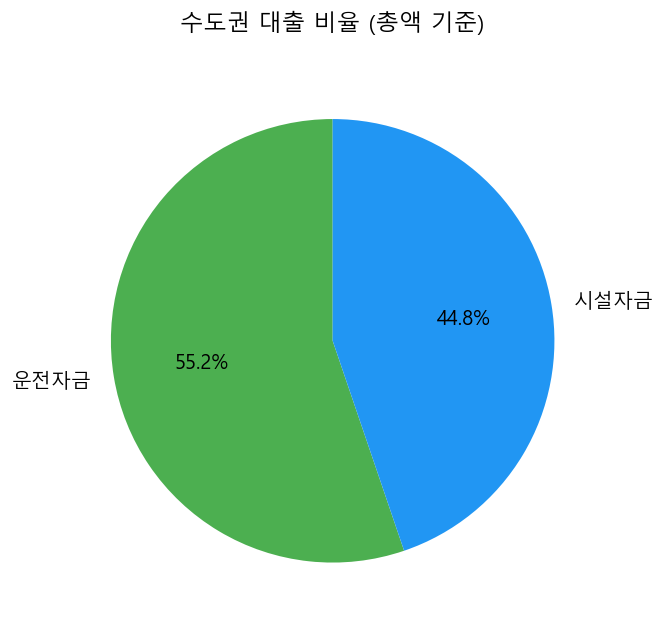

In [ ]:
import matplotlib.pyplot as plt

# 수도권 대출 총액 데이터
categories = ['운전자금', '시설자금']
amounts = [65333760.4, 52979246.0]  # 총액

# 원형 차트 생성
fig, ax = plt.subplots(figsize=(6,6))
ax.pie(
    amounts, 
    labels=categories, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['#4CAF50', '#2196F3'],  # 녹색=운전자금, 파랑=시설자금
    textprops={'fontsize':12}
)
ax.set_title('수도권 대출 비율 (총액 기준)', fontsize=14, pad=20)

plt.show()